In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

from analysis.gravnet.model import NeutrinoGravNetRegressionFASER
from analysis.utils.utils import get_torch_path, get_weights_path, get_figures_path

WEIGHTS_DIR = "gravnet_regression_faser_all_events_mean_reparam"
RUN = 10000
DATA_TYPE = "all"
BATCH_SIZE = 8

TARGET_NAMES = ["E_nu", "E_lepton", "E_roe"]
TARGET_LATEX = [r"$E_\nu$", r"$E_\mathrm{lep}$", r"$E_\mathrm{roe}$"]
TARGET_UNITS = "TeV"

ENERGY_BINS_TEV = [
    (0.01, 0.05), (0.05, 0.1), (0.1, 0.2),
    (0.2,  0.3),  (0.3,  0.5), (0.5,  0.7),
    (0.7,  1.0),  (1.0,  1.5), (1.5,  3.0),
]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

weights_path = get_weights_path() / WEIGHTS_DIR
torch_path   = get_torch_path()
figures_path = get_figures_path() / WEIGHTS_DIR
figures_path.mkdir(parents=True, exist_ok=True)

print(f"Weights : {weights_path}")
print(f"Figures : {figures_path}")

Device: cuda:0
Weights : /gluster/home/sgoncalves/PinpointDetector/PinpointAnalysis/../data/weights/gravnet_regression_faser_all_events_mean_reparam
Figures : /gluster/home/sgoncalves/PinpointDetector/PinpointAnalysis/../figures/gravnet_regression_faser_all_events_mean_reparam


**Training curves**

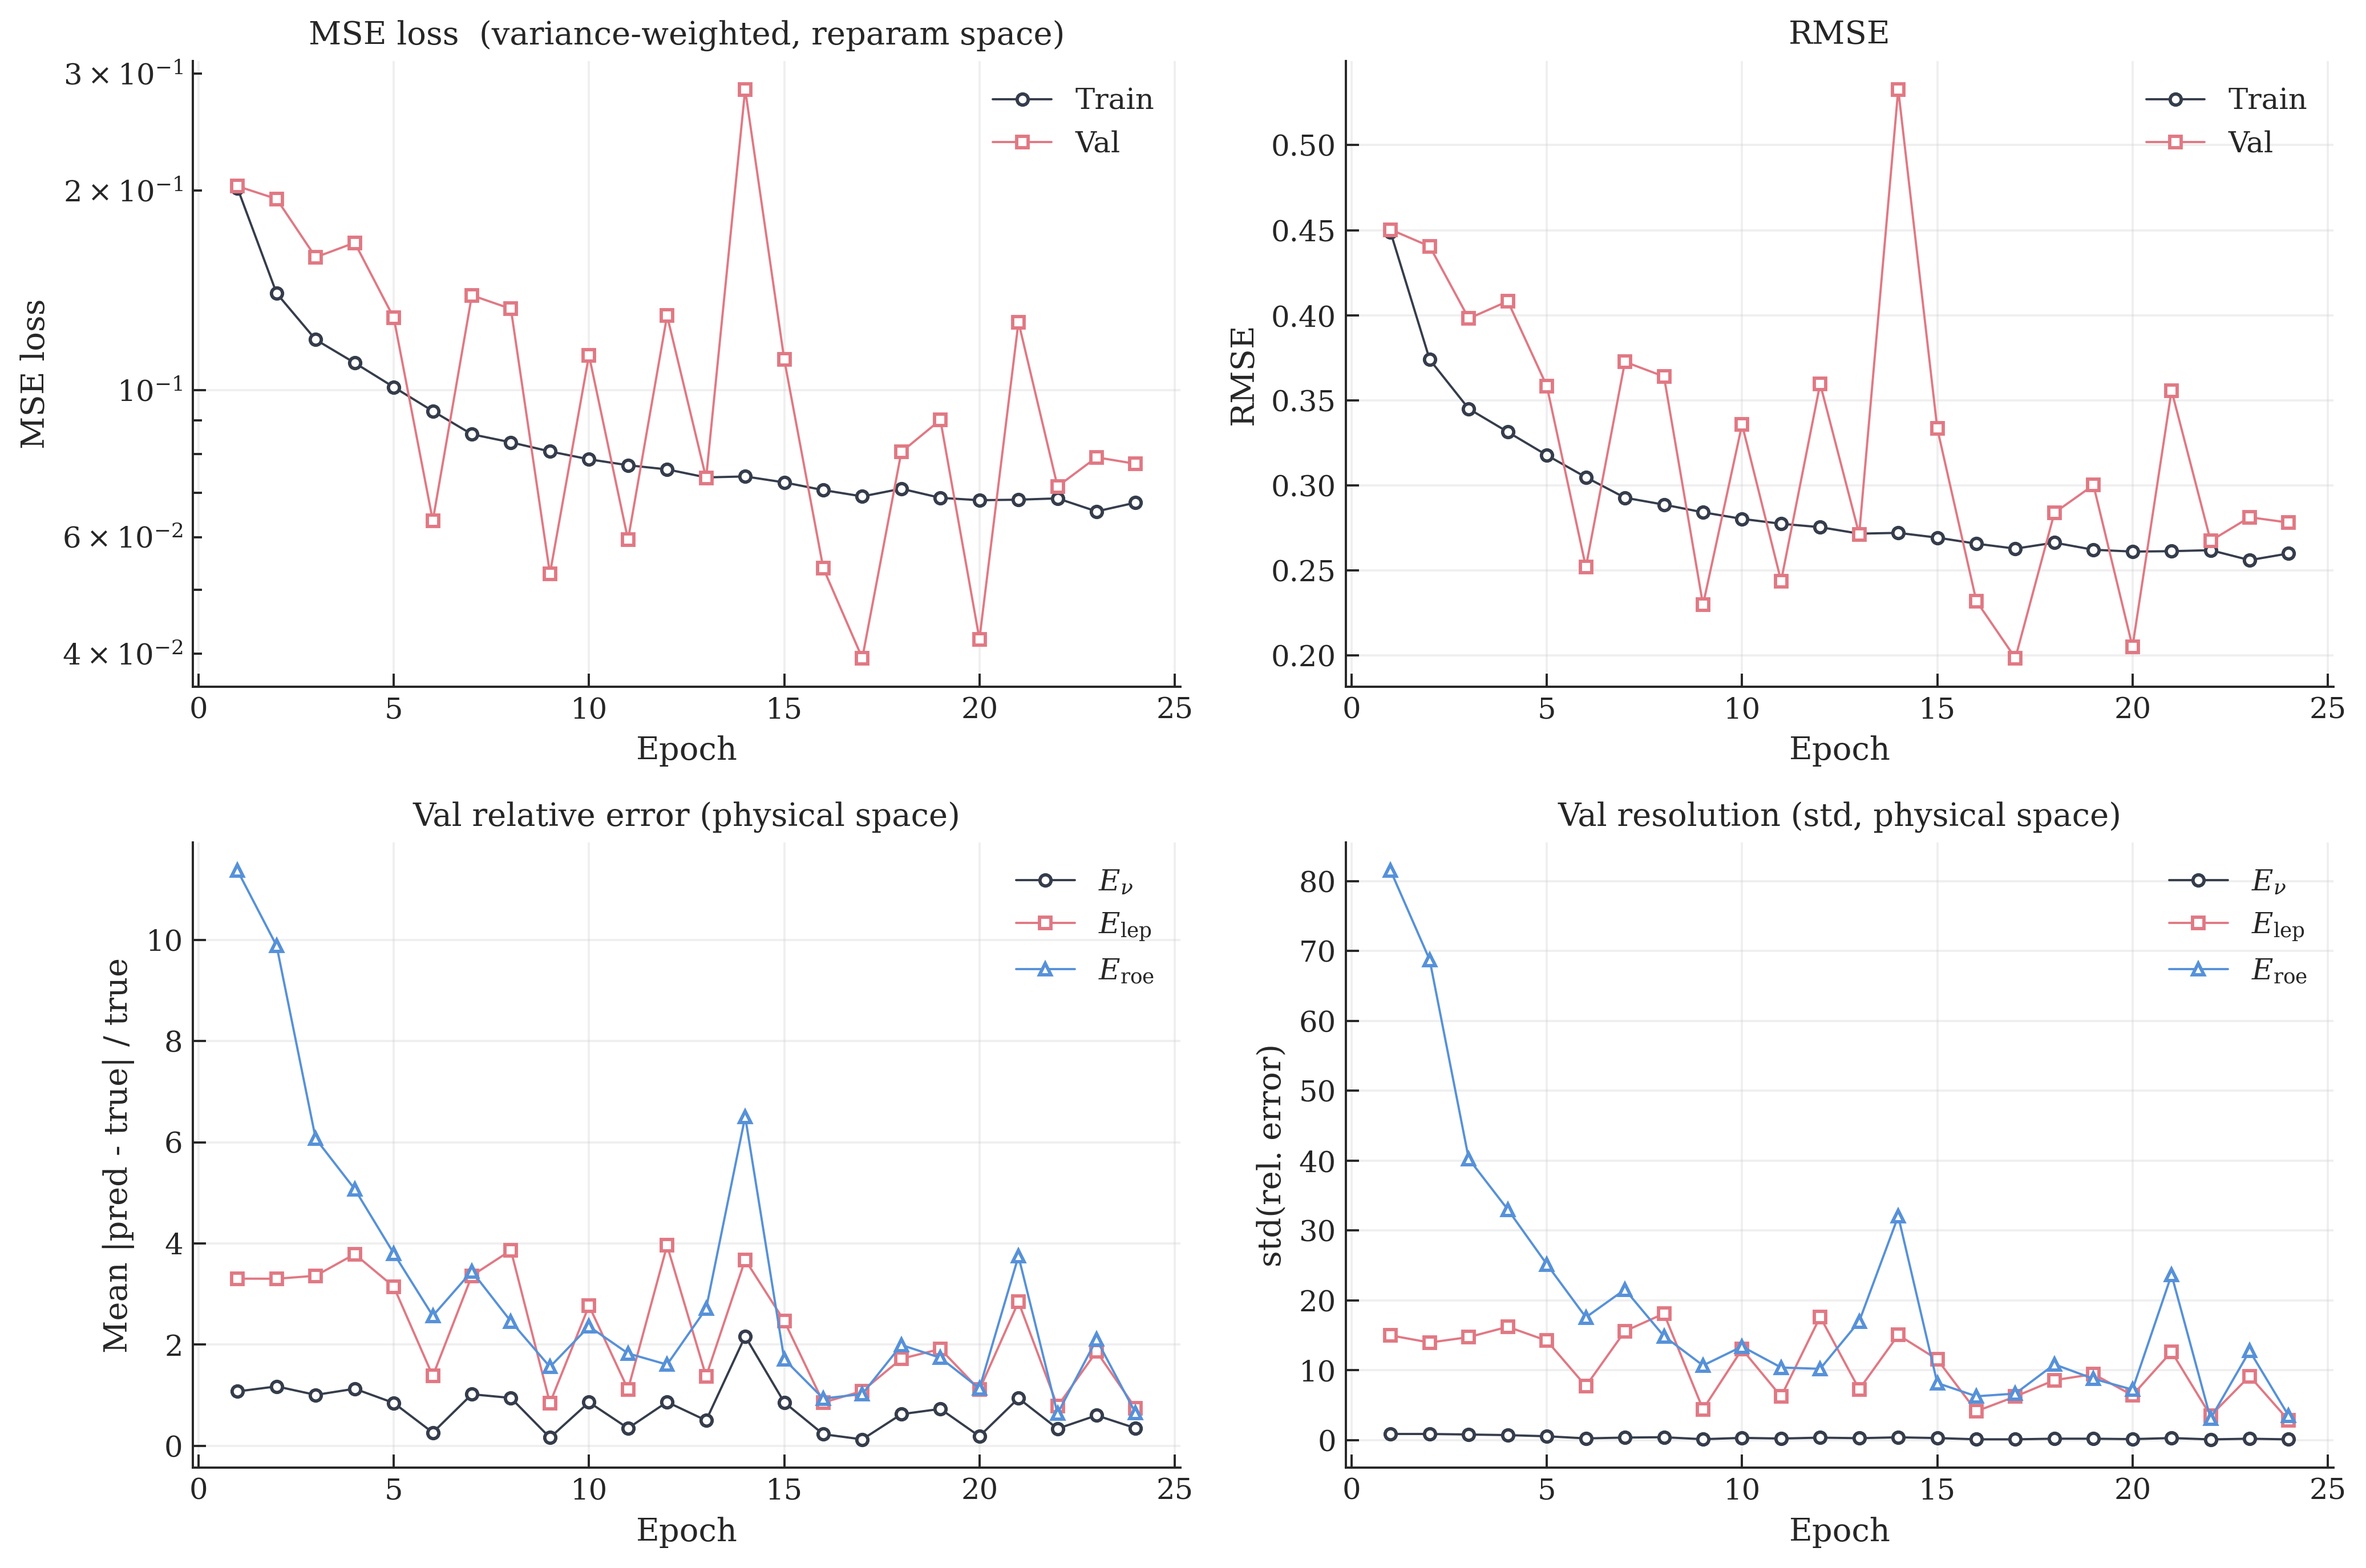

Saved: training_curves.png


In [58]:
import seaborn as sns

sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'figure.dpi': 350,
})

C1 = "#353D4C"   # dark blue-gray — train / E_nu
C2 = "#E17883"   # muted red      — val   / E_lepton
C3 = "#5691D9"   # muted blue     — E_roe
MARKER_KW = dict(markersize=4, markerfacecolor='white', markeredgewidth=1.2)

metrics = np.load(weights_path / "training_metrics.npz")
epochs  = np.arange(1, len(metrics["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.plot(epochs, metrics["train_loss"], marker='o', linewidth=0.8, color=C1, label="Train", **MARKER_KW)
ax.plot(epochs, metrics["val_loss"],   marker='s', linewidth=0.8, color=C2, label="Val",   **MARKER_KW)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend(frameon=False)
ax.set_title("MSE loss  (variance-weighted, reparam space)")
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs, metrics["train_rmse"], marker='o', linewidth=0.8, color=C1, label="Train", **MARKER_KW)
ax.plot(epochs, metrics["val_rmse"],   marker='s', linewidth=0.8, color=C2, label="Val",   **MARKER_KW)
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.legend(frameon=False)
ax.set_title("RMSE")
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for i, (latex, c, m) in enumerate(zip(TARGET_LATEX, [C1, C2, C3], ['o', 's', '^'])):
    ax.plot(epochs, metrics["val_rel_err"][:, i], marker=m, linewidth=0.8, color=c, label=latex, **MARKER_KW)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean |pred - true| / true")
ax.legend(frameon=False)
ax.set_title("Val relative error (physical space)")
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for i, (latex, c, m) in enumerate(zip(TARGET_LATEX, [C1, C2, C3], ['o', 's', '^'])):
    ax.plot(epochs, metrics["val_resolution"][:, i], marker=m, linewidth=0.8, color=c, label=latex, **MARKER_KW)
ax.set_xlabel("Epoch")
ax.set_ylabel("std(rel. error)")
ax.legend(frameon=False)
ax.set_title("Val resolution (std, physical space)")
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / "training_curves.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

**Model and data**

In [59]:
# Load checkpoint
checkpoint = torch.load(weights_path / "best_model.pt", weights_only=False)
print(f"Best model from epoch {checkpoint['epoch'] + 1},  "
      f"val_loss={checkpoint['val_loss']:.4f},  "
      f"val_rmse={checkpoint['val_rmse']:.4f}")
if "loss_weights" in checkpoint:
    w_enu, w_logit = checkpoint["loss_weights"]
    print(f"Loss weights: w_enu={w_enu:.4f}, w_logit={w_logit:.4f}")
if "parametrisation" in checkpoint:
    print(f"Parametrisation: {checkpoint['parametrisation']}")

# Derive pooling from directory name so it always matches the trained run
pooling = "sum" if "_sum_" in WEIGHTS_DIR else "mean"
print(f"Pooling: {pooling}")

# Reconstruct model — args must match training exactly
model = NeutrinoGravNetRegressionFASER(
    input_dim=1,      # log10(n_hits) per super-pixel
    num_targets=2,    # log10(E_nu), logit(y = E_lepton/E_nu)
    faser_dim=5,      # nhits_0, nhits_1, nhits_2, faser_x, faser_y
    pooling=pooling,
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()
print("Model loaded and set to eval mode.")

# Load the same data as training and reproduce the identical val split.
# train_test_split(random_state=42) is deterministic so we get the same 20%.
run_str  = "nue"   # run 10000 % 4 == 0 → nue
run_path = torch_path / f"{RUN}/pointnetpp_faser_{DATA_TYPE}_events"
chunk_files = sorted(run_path.glob(f"{run_str}_*.pt"))

dataset = []
for f in chunk_files:
    dataset.extend(torch.load(f, weights_only=False))
print(f"Loaded {len(dataset)} events from {len(chunk_files)} chunks.")

_, val_dataset = train_test_split(dataset, test_size=0.2, random_state=42)
print(f"Val set: {len(val_dataset)} events.")

# Larger batch + parallel workers for faster inference (no gradient memory constraint)
val_loader = DataLoader(
    val_dataset, batch_size=256, shuffle=False,
    num_workers=4, pin_memory=(device.type == "cuda"),
)

# Inference cache key — encodes the specific checkpoint
cache_key  = f"ep{checkpoint['epoch']}_vl{checkpoint['val_loss']:.6f}"
cache_path = weights_path / f"inference_cache_{cache_key}.npz"

Best model from epoch 17,  val_loss=0.0394,  val_rmse=0.1986
Loss weights: w_enu=0.9686, w_logit=0.0314
Parametrisation: reparam
Pooling: mean
Model loaded and set to eval mode.
Loaded 7076 events from 10 chunks.
Val set: 1416 events.


**Inference**

Model outputs are `(log10(E_nu), logit(y))` where `y = E_lepton / E_nu` (inelasticity). Physical energies are recovered as:

```
E_nu     = 10 ** pred[:,0]
y        = sigmoid(pred[:,1])
E_lepton = y * E_nu
E_roe    = (1 - y) * E_nu
```

Energy conservation `E_lepton + E_roe = E_nu` holds exactly by construction. Targets in the dataset are raw linear TeV.

Loading inference from cache: inference_cache_ep16_vl0.039427.npz
Loaded 1416 events.
Inference done: 1416 events
  E_nu        : true [0.0276, 3.5130] TeV
  E_lepton    : true [0.0012, 2.8003] TeV
  E_roe       : true [0.0003, 2.9935] TeV


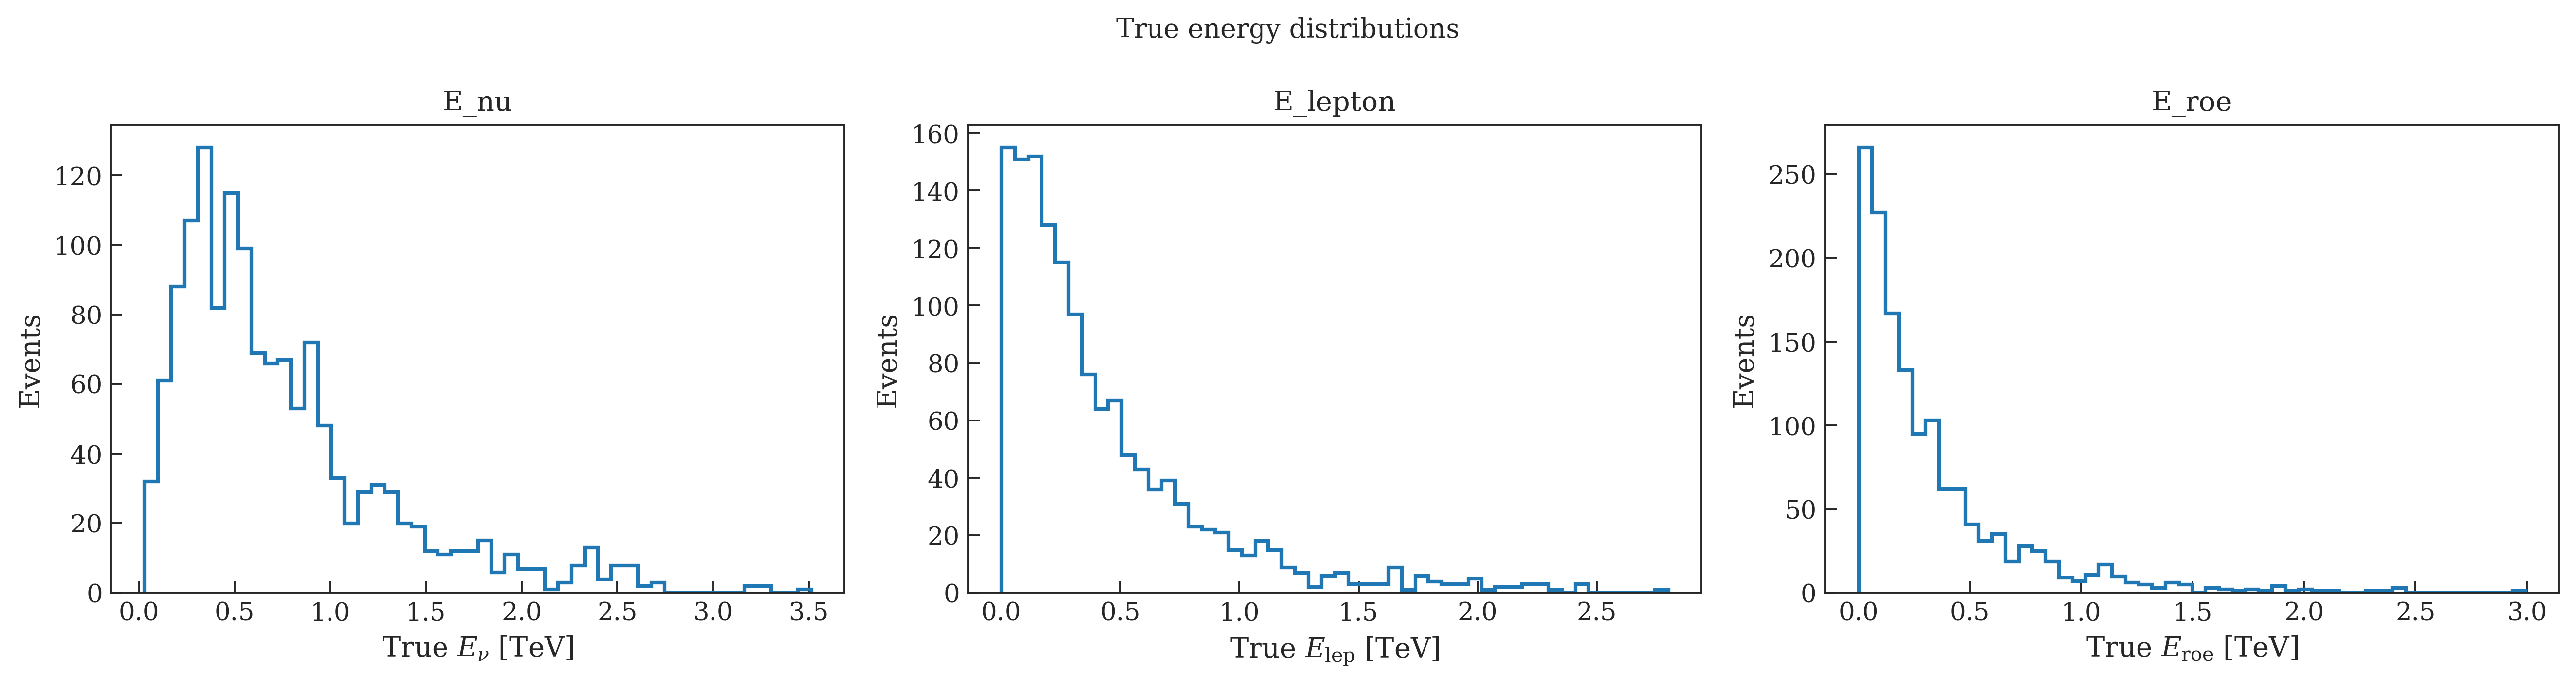

In [60]:
def preds_to_physical(preds):
    """
    Convert reparametrised model outputs to physical energies (TeV).
    preds: [N, 2] torch tensor — col 0: log10(E_nu), col 1: logit(y)
    Returns [N, 3] numpy array — (E_nu, E_lepton, E_roe) in TeV
    """
    E_nu  = 10 ** preds[:, 0]
    y     = torch.sigmoid(preds[:, 1])
    E_lep = y * E_nu
    E_roe = (1 - y) * E_nu
    return torch.stack([E_nu, E_lep, E_roe], dim=1).numpy()


if cache_path.exists():
    print(f"Loading inference from cache: {cache_path.name}")
    _c = np.load(cache_path)
    preds_raw      = torch.from_numpy(_c['preds_raw'])
    targets_linear = _c['targets_linear']
    preds_linear   = preds_to_physical(preds_raw)
    print(f"Loaded {len(preds_linear)} events.")
else:
    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for data in val_loader:
            data    = data.to(device)
            raw     = model(data.x, data.pos, data.batch, data.x_faser)  # [B, 2]
            targets = torch.stack([data.E_nu, data.E_lepton, data.E_roe], dim=1)  # [B, 3] linear TeV
            all_preds.append(raw.cpu())
            all_targets.append(targets.cpu())

    preds_raw      = torch.cat(all_preds)             # [N, 2]  raw model output
    targets_linear = torch.cat(all_targets).numpy()   # [N, 3]  TeV
    preds_linear   = preds_to_physical(preds_raw)     # [N, 3]  TeV

    np.savez_compressed(cache_path,
                        preds_raw=preds_raw.numpy(),
                        targets_linear=targets_linear)
    print(f"Saved inference cache: {cache_path.name}")

print(f"Inference done: {len(preds_linear)} events")
for i, name in enumerate(TARGET_NAMES):
    print(f"  {name:12s}: true [{targets_linear[:, i].min():.4f}, "
          f"{targets_linear[:, i].max():.4f}] TeV")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, latex) in enumerate(zip(TARGET_NAMES, TARGET_LATEX)):
    axes[i].hist(targets_linear[:, i], bins=50, histtype="step", linewidth=1.5)
    axes[i].set_xlabel(f"True {latex} [TeV]")
    axes[i].set_ylabel("Events")
    axes[i].set_title(name)
plt.suptitle("True energy distributions", fontsize=11)
plt.tight_layout()
plt.show()

**True vs reconstructed energy**

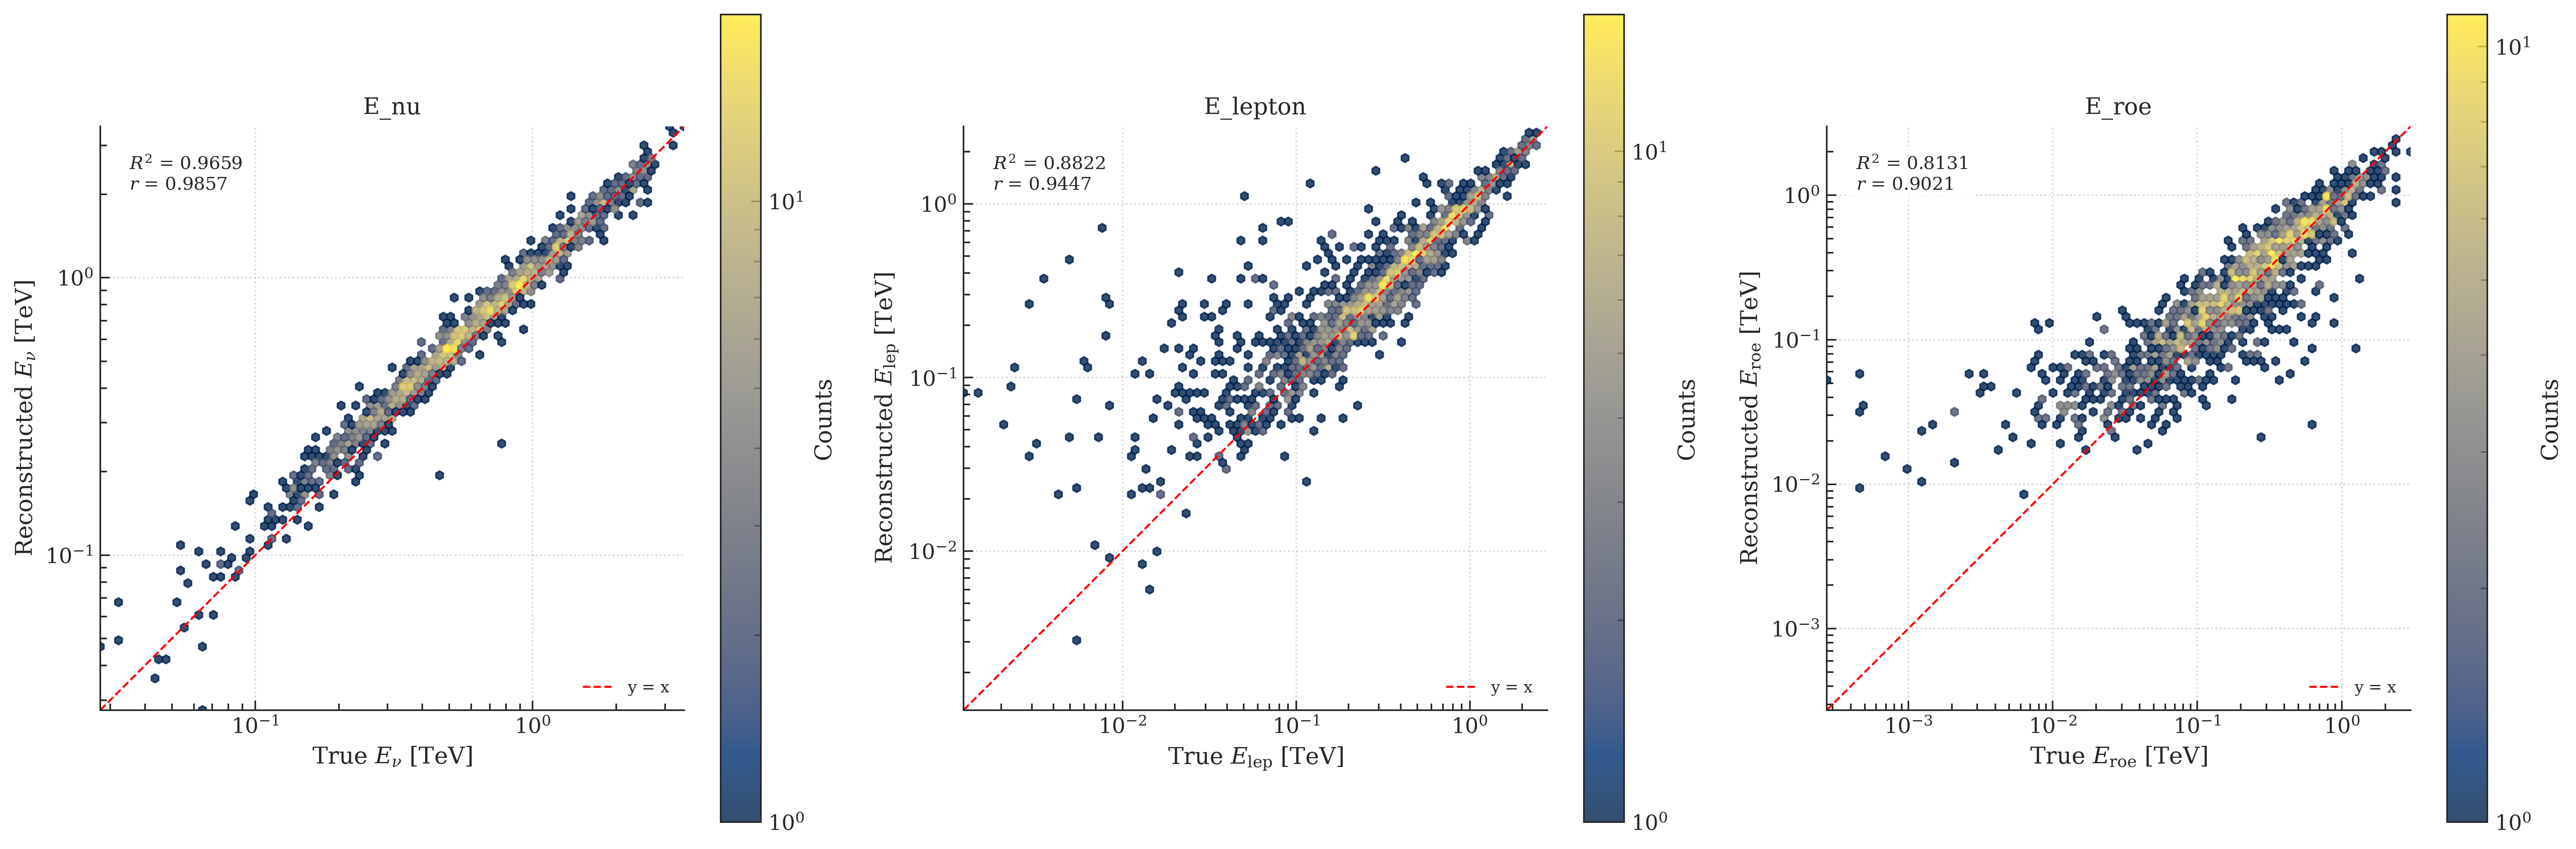

Saved: true_vs_reco.png

Target               R²    Pearson r
E_nu             0.9659       0.9857
E_lepton         0.8822       0.9447
E_roe            0.8131       0.9021


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, latex) in enumerate(zip(TARGET_NAMES, TARGET_LATEX)):
    ax     = axes[i]
    y_true = targets_linear[:, i]
    y_pred = preds_linear[:, i]

    # Metrics
    ss_res    = np.sum((y_true - y_pred) ** 2)
    ss_tot    = np.sum((y_true - y_true.mean()) ** 2)
    r2        = 1 - ss_res / ss_tot
    pearson_r = np.corrcoef(y_true, y_pred)[0, 1]

    # Axis range from true values only — keeps the plot square and clips prediction outliers
    lo = max(y_true.min(), 1e-6)
    hi = y_true.max()

    hb = ax.hexbin(y_true, y_pred,
                   xscale='log', yscale='log',
                   gridsize=80, cmap='cividis', bins='log',
                   mincnt=1, alpha=0.8,
                   extent=[np.log10(lo), np.log10(hi),
                           np.log10(lo), np.log10(hi)])
    plt.colorbar(hb, ax=ax, label='Counts')

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal')

    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
    ax.set_xlabel(rf"True {latex} [{TARGET_UNITS}]")
    ax.set_ylabel(rf"Reconstructed {latex} [{TARGET_UNITS}]")
    ax.legend(fontsize=8, frameon=False)
    ax.set_title(name)
    ax.text(
        0.05, 0.95,
        f"$R^2$ = {r2:.4f}\n$r$ = {pearson_r:.4f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
    )
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / "true_vs_reco.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: true_vs_reco.png")
print()
print(f"{'Target':<12} {'R²':>10} {'Pearson r':>12}")
for i, name in enumerate(TARGET_NAMES):
    y_true = targets_linear[:, i]
    y_pred = preds_linear[:, i]
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    r  = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"{name:<12} {r2:>10.4f} {r:>12.4f}")

**Resolution histograms per energy bin**

Resolution = (pred − true) / true per event. A value of +0.3 means the prediction was 30% too high. These histograms show the full distribution shape in each energy bin — not just the width, but also symmetry and tail behaviour. The Gaussian fit gives mu (systematic offset) and sigma (spread).

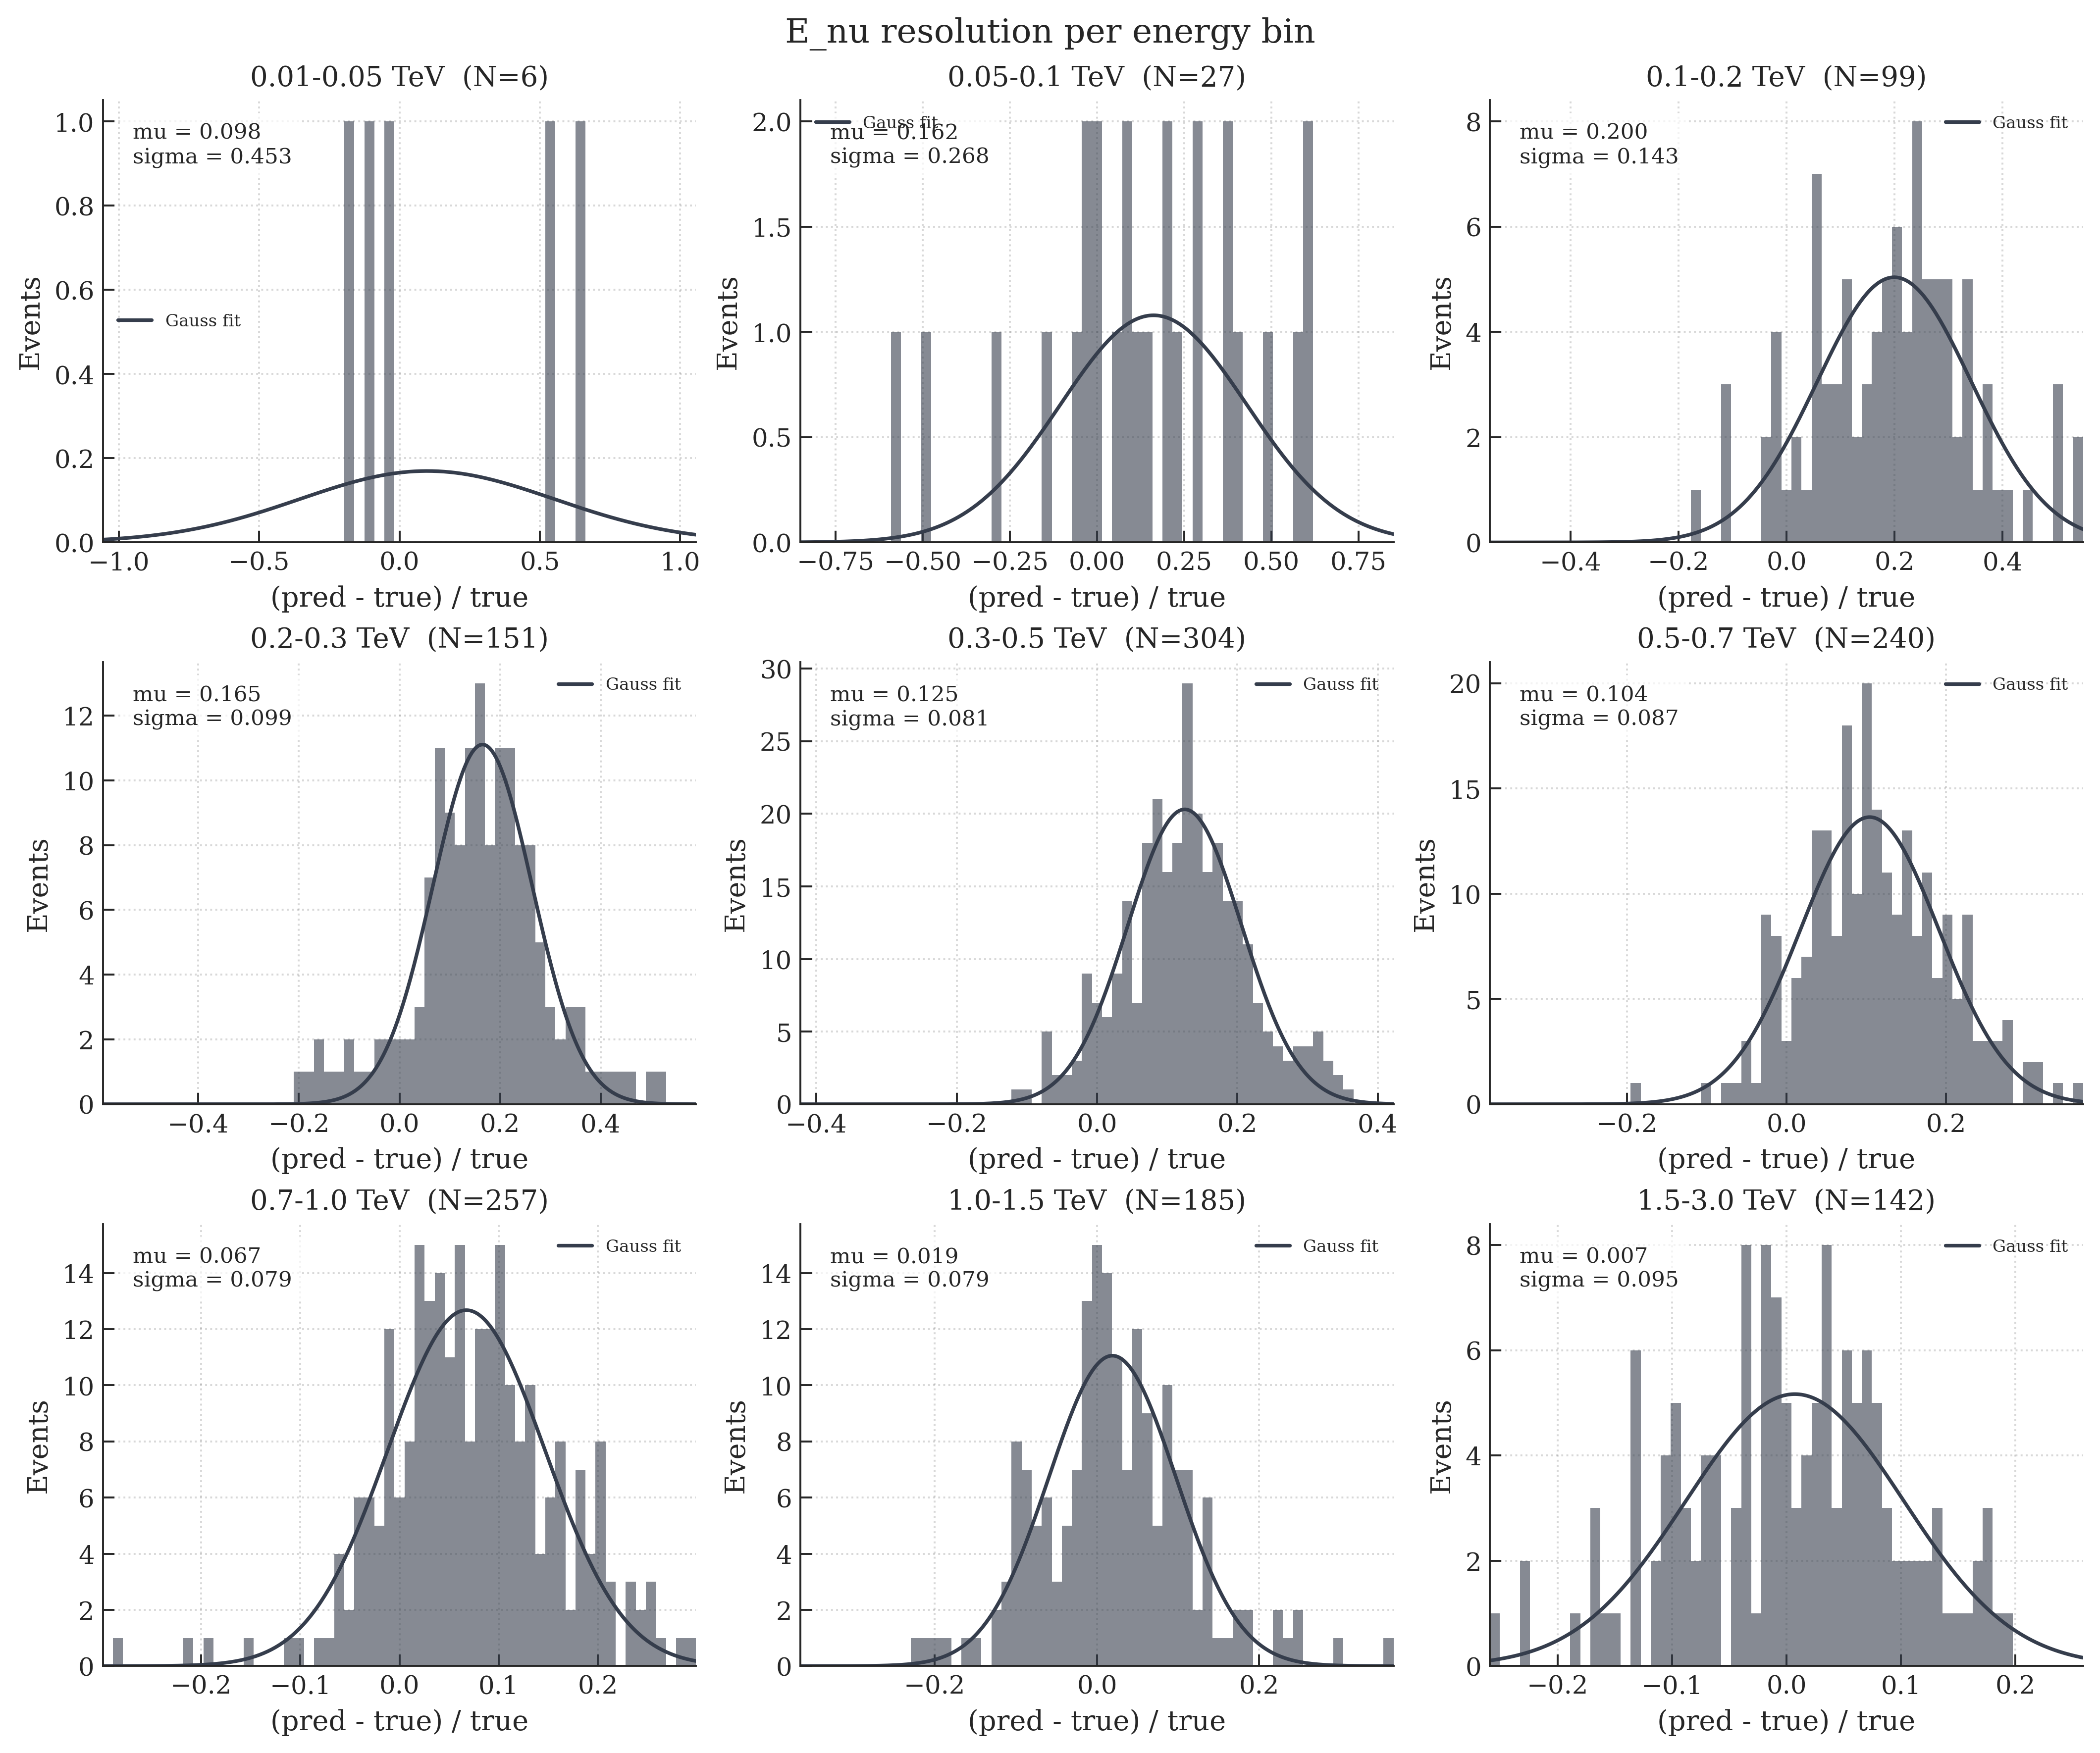

Saved: E_nu_ResolutionPerBin.png


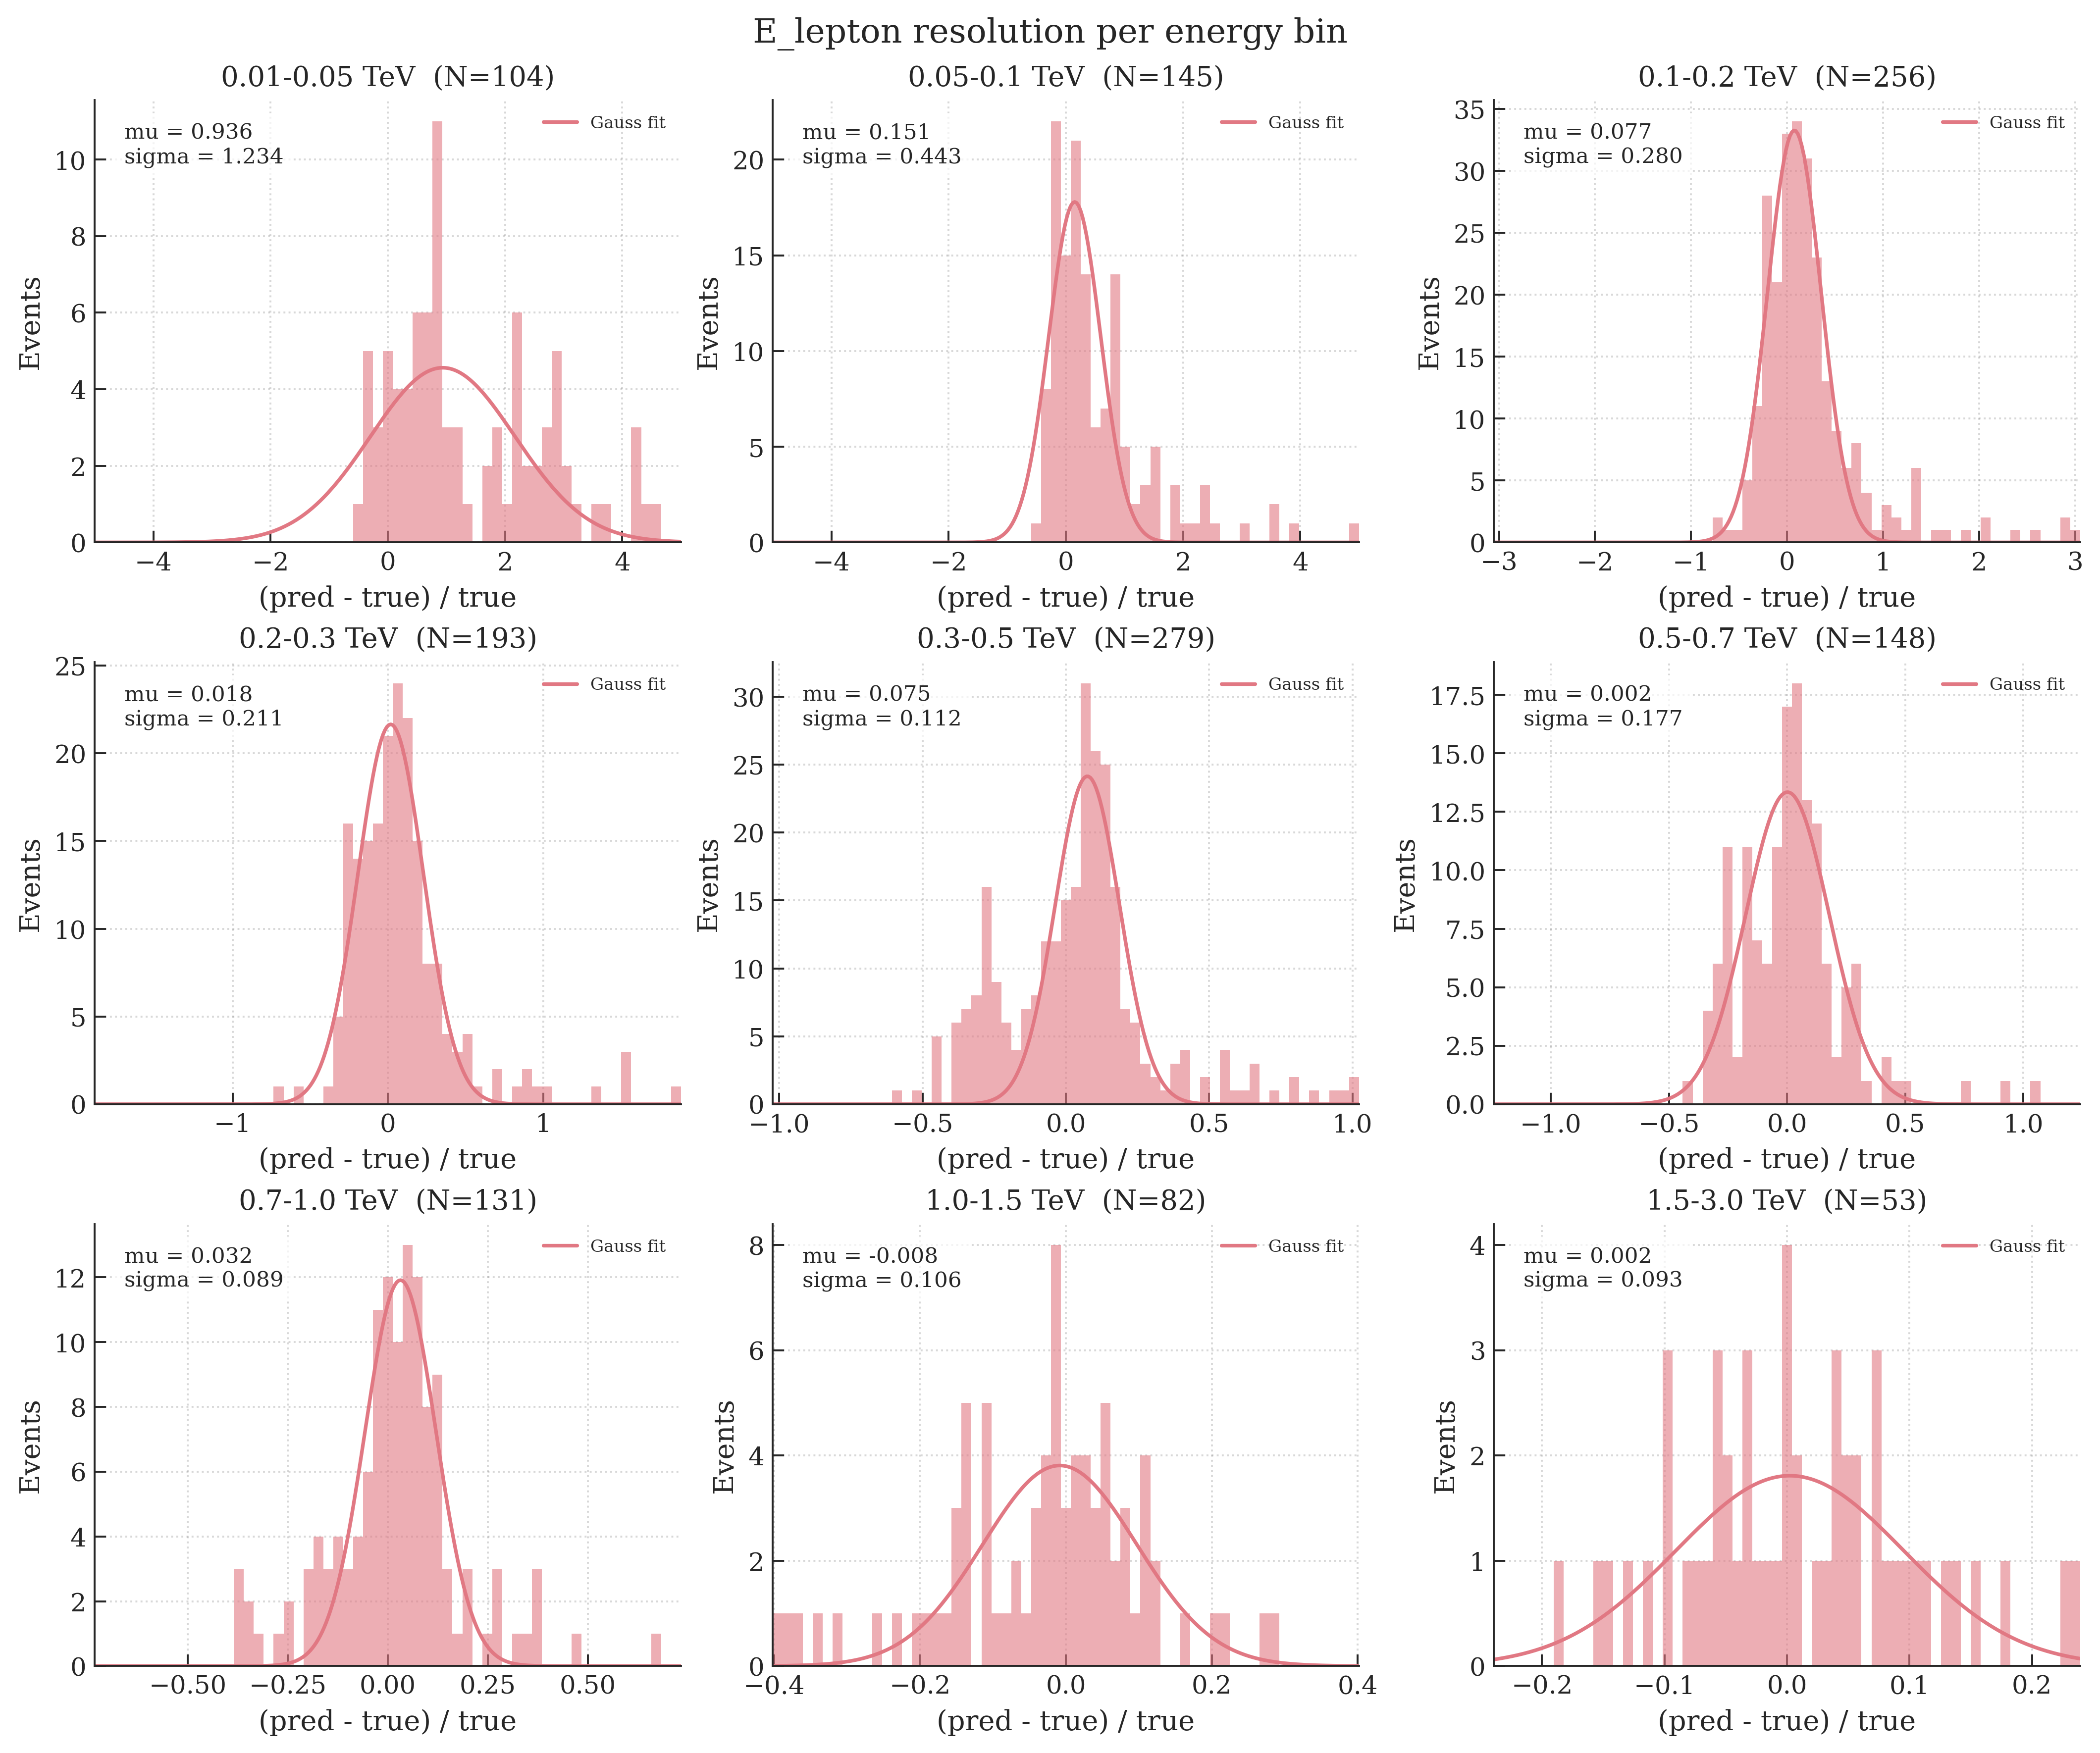

Saved: E_lepton_ResolutionPerBin.png


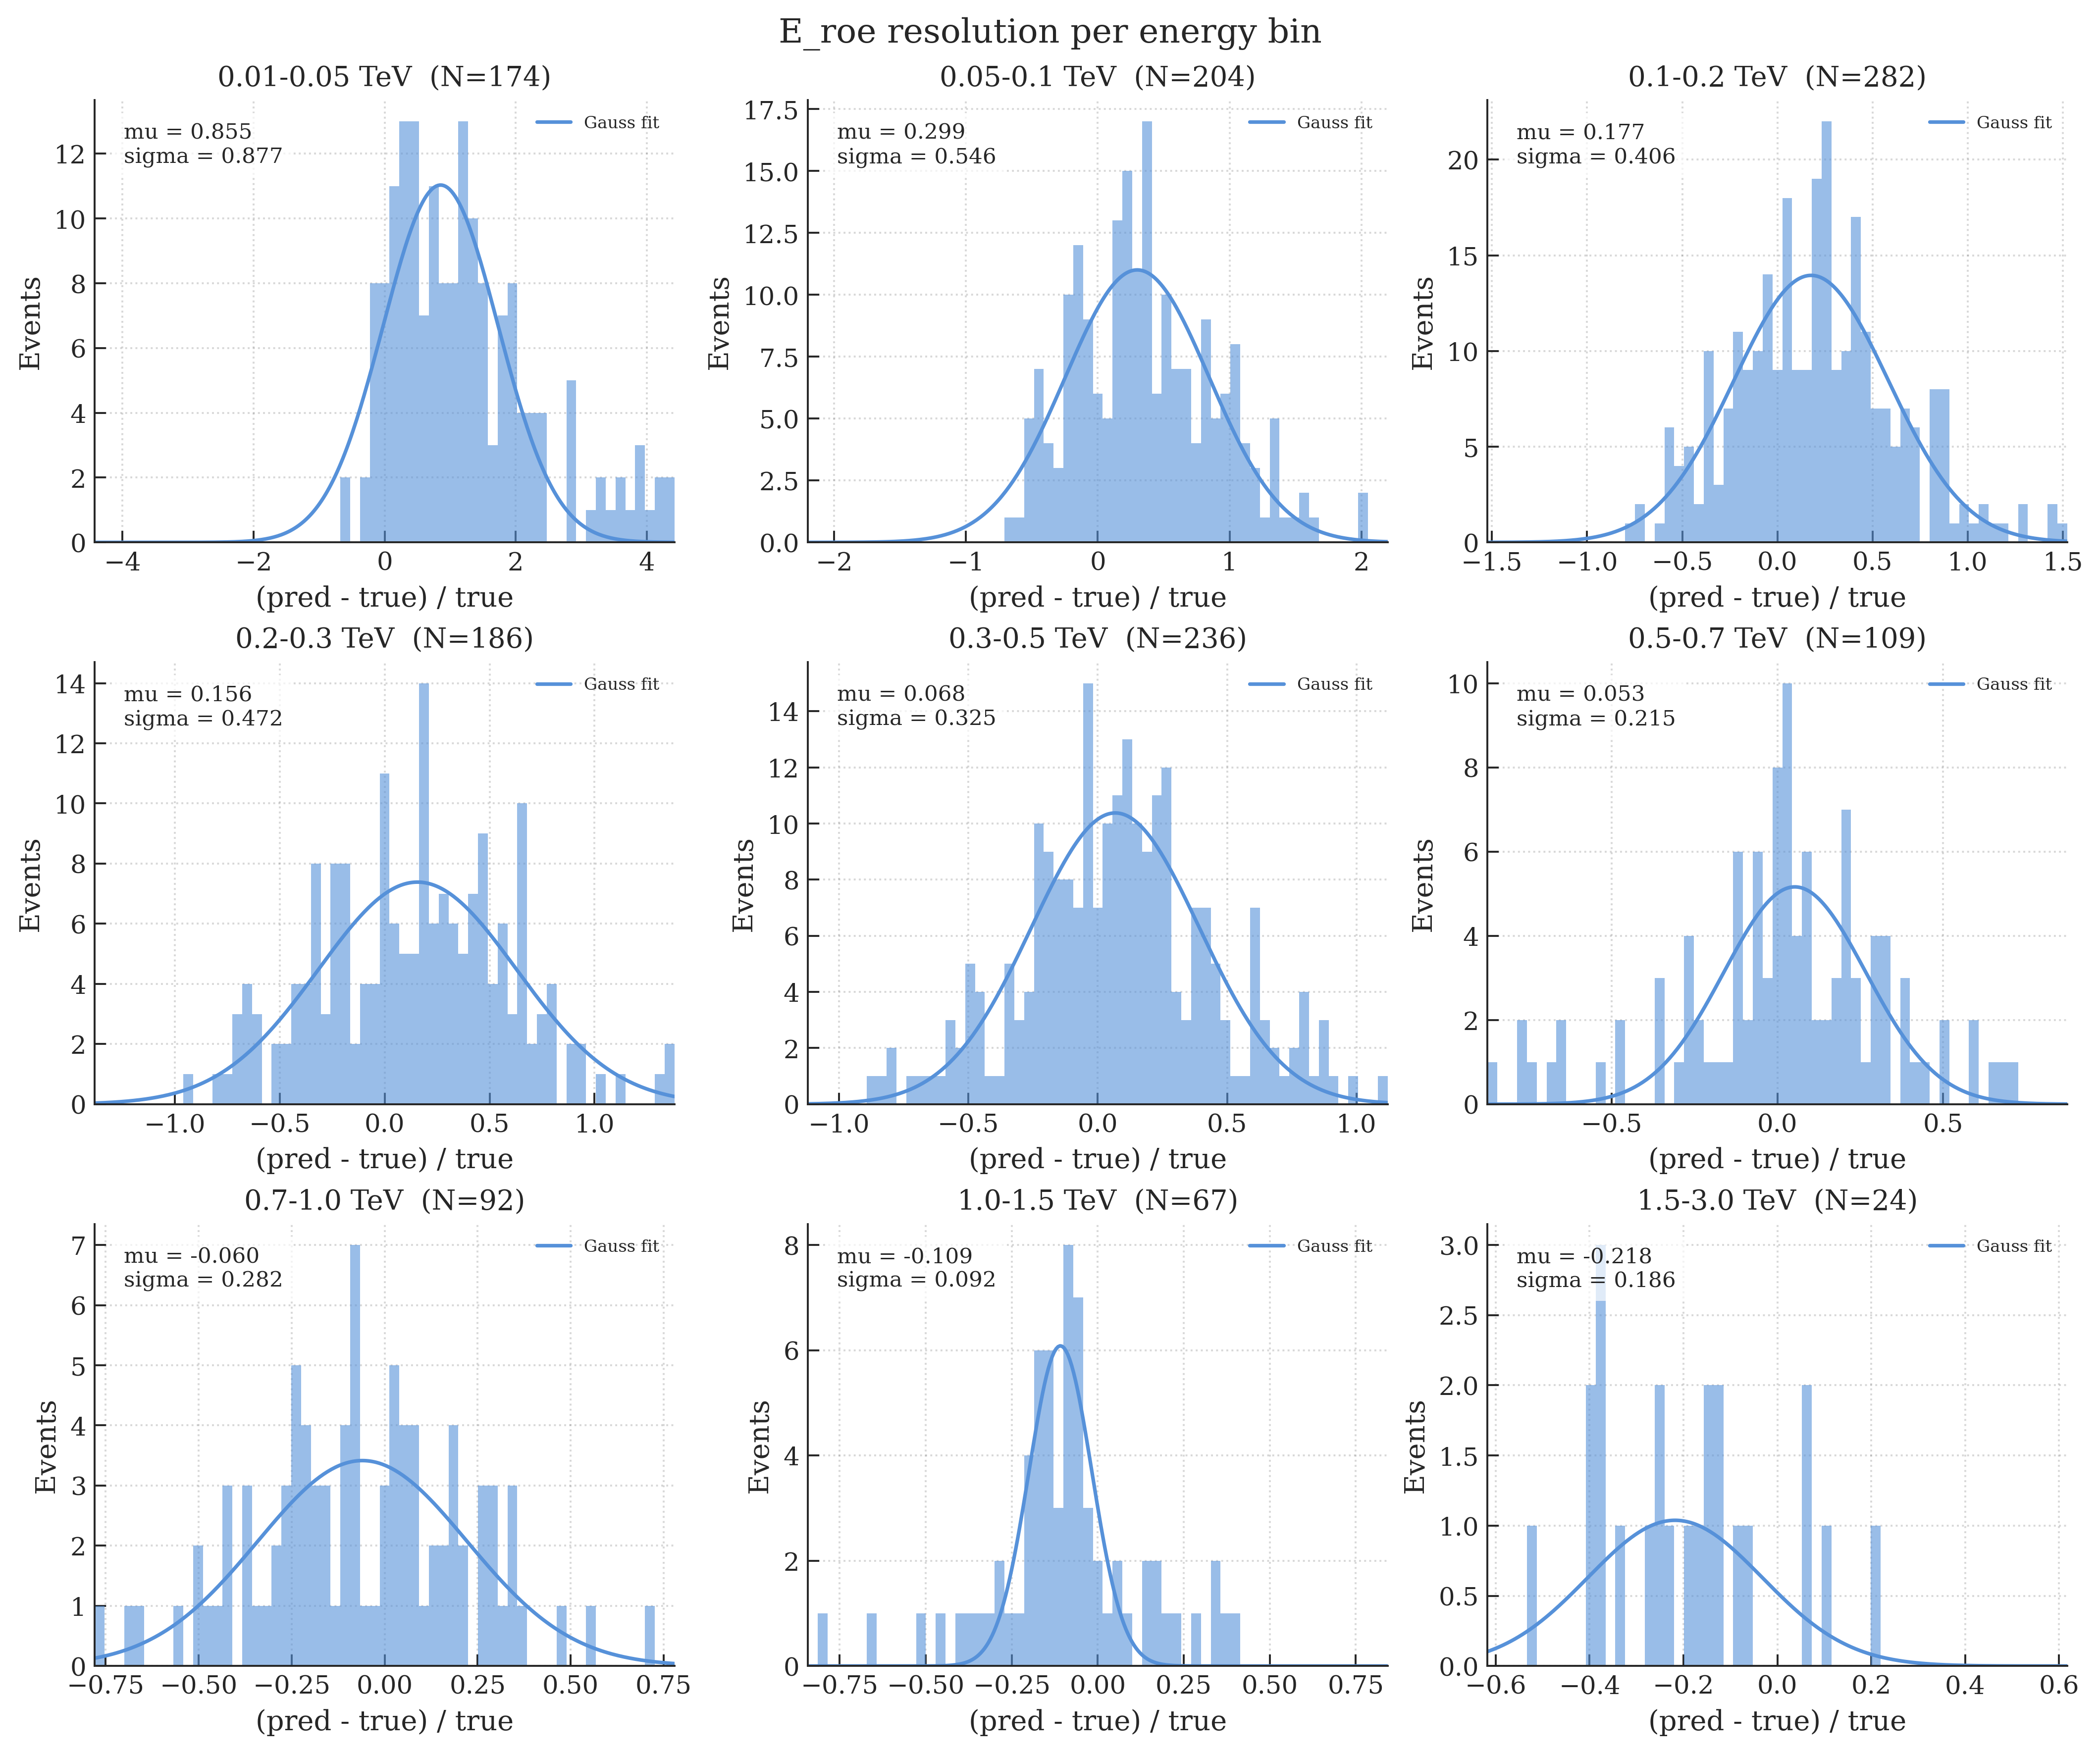

Saved: E_roe_ResolutionPerBin.png


In [62]:
def gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

for target_idx, (name, latex, col) in enumerate(zip(TARGET_NAMES, TARGET_LATEX, [C1, C2, C3])):
    y_true     = targets_linear[:, target_idx]
    y_pred     = preds_linear[:, target_idx]
    resolution = (y_pred - y_true) / y_true

    fig, axes_grid = plt.subplots(3, 3, figsize=(12, 10), constrained_layout=True)
    axes_flat = axes_grid.flatten()

    for j, (emin, emax) in enumerate(ENERGY_BINS_TEV):
        if j >= 9:
            break
        ax      = axes_flat[j]
        mask    = (y_true >= emin) & (y_true < emax)
        res_bin = resolution[mask]

        if len(res_bin) == 0:
            ax.text(0.5, 0.5, "No events", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_title(f"{emin}-{emax} TeV")
            continue

        p1, p99  = np.percentile(res_bin, [1, 99])
        xlim     = min(max(abs(p1), abs(p99), 0.1), 5.0)
        bins_arr = np.linspace(-xlim, xlim, 60)

        counts, bin_edges, _ = ax.hist(
            res_bin, bins=bins_arr,
            histtype='stepfilled', alpha=0.6, color=col, linewidth=0,
        )

        bin_centers_fit = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        try:
            popt_g, _ = curve_fit(
                gauss, bin_centers_fit, counts,
                p0=[counts.max(), np.mean(res_bin), np.std(res_bin)],
                maxfev=5000,
            )
            sigma_fit = abs(popt_g[2])
            x_gauss   = np.linspace(-xlim, xlim, 300)
            ax.plot(x_gauss, gauss(x_gauss, *popt_g),
                    color=col, linewidth=1.5, alpha=1.0, label="Gauss fit")
            label_text = f"mu = {popt_g[1]:.3f}\nsigma = {sigma_fit:.3f}"
            ax.legend(fontsize=7, frameon=False)
        except (RuntimeError, ValueError):
            label_text = f"mean = {np.mean(res_bin):.3f}\nstd  = {np.std(res_bin):.3f}"

        ax.set_title(f"{emin}-{emax} TeV  (N={len(res_bin)})")
        ax.set_xlabel("(pred - true) / true")
        ax.set_ylabel("Events")
        ax.set_xlim(-xlim, xlim)
        ax.text(
            0.05, 0.95, label_text,
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        )
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)

    fig.suptitle(f"{name} resolution per energy bin", fontsize=14)
    plt.savefig(figures_path / f"{name}_ResolutionPerBin.png", dpi=500, bbox_inches='tight')
    plt.show()
    print(f"Saved: {name}_ResolutionPerBin.png")

**Resolution vs energy**

std of (pred − true) / true in each energy bin. Should decrease with energy as higher-energy showers produce more hits and are easier to reconstruct.

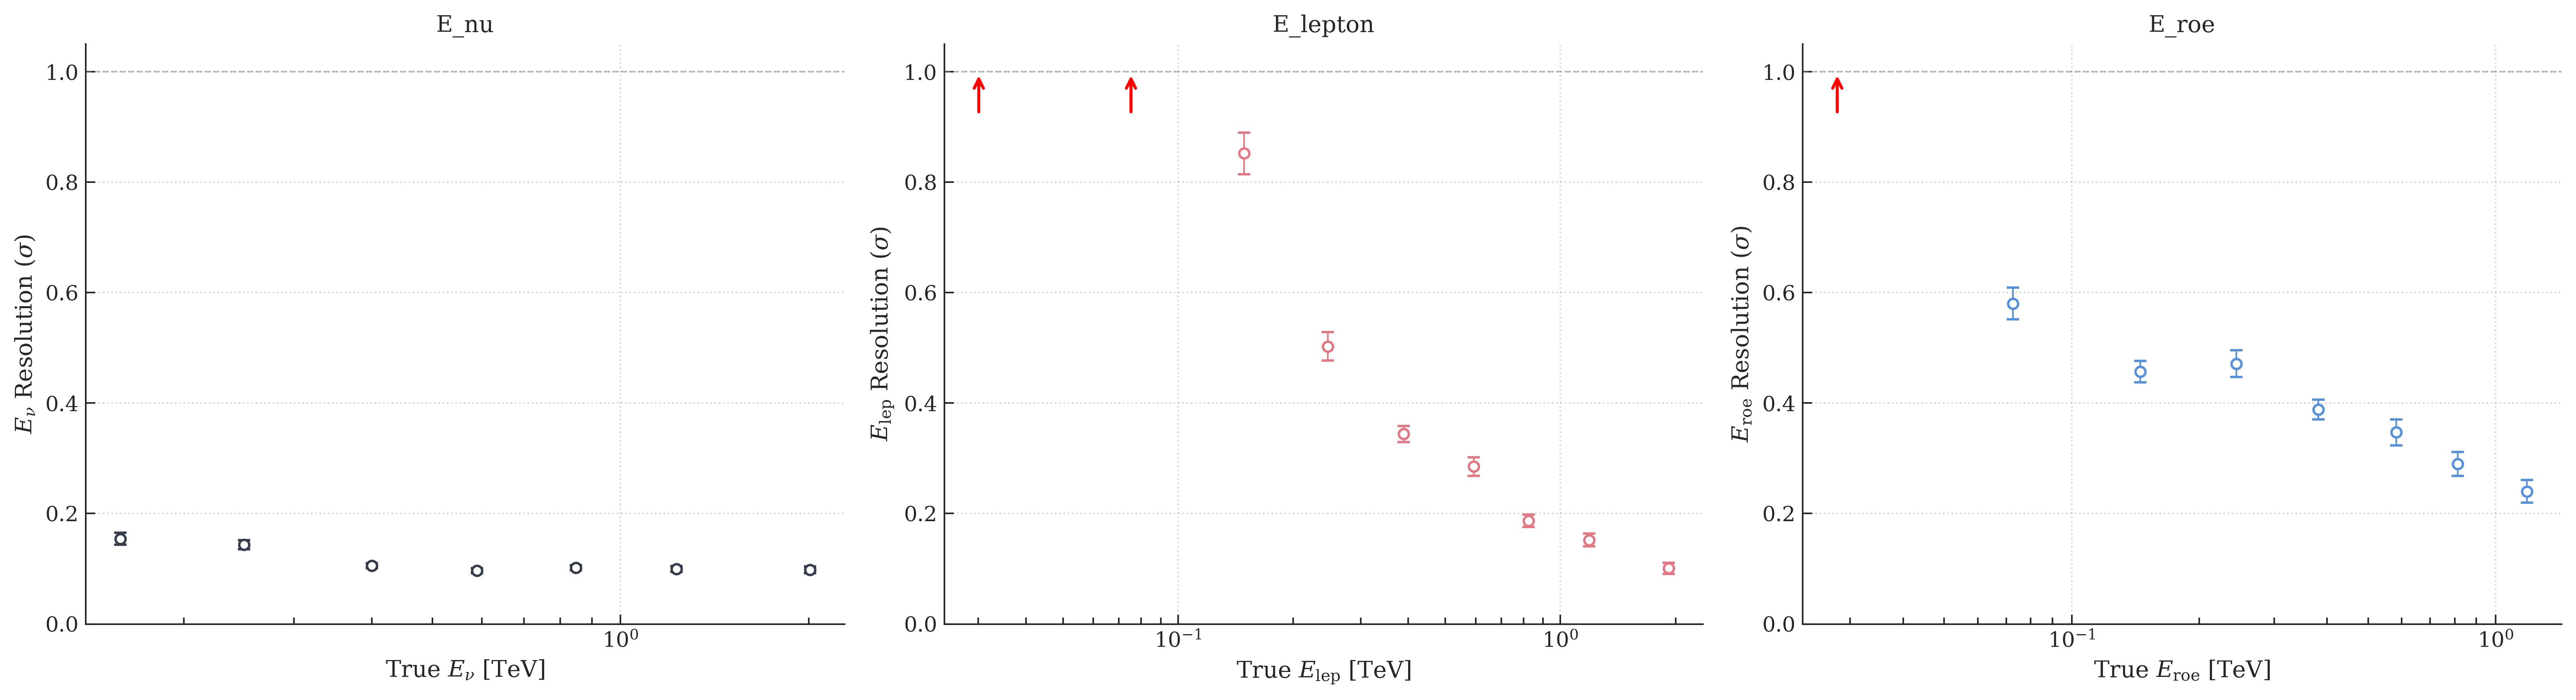

Saved: resolution_vs_true.png


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for target_idx, (name, latex, col) in enumerate(zip(TARGET_NAMES, TARGET_LATEX, [C1, C2, C3])):
    ax         = axes[target_idx]
    y_true     = targets_linear[:, target_idx]
    y_pred     = preds_linear[:, target_idx]
    resolution = (y_pred - y_true) / y_true

    bin_centers = []
    sigmas      = []
    sigma_errs  = []

    for emin, emax in ENERGY_BINS_TEV:
        mask    = (y_true >= emin) & (y_true < emax)
        res_bin = resolution[mask]

        if len(res_bin) < 50:   # skip underpopulated bins
            continue

        sigma     = np.std(res_bin)
        sigma_err = sigma / np.sqrt(2 * len(res_bin))
        center    = np.mean(y_true[mask])

        bin_centers.append(center)
        sigmas.append(sigma)
        sigma_errs.append(sigma_err)

    if bin_centers:
        ax.errorbar(bin_centers, sigmas, yerr=sigma_errs,
                    fmt='o', markersize=5, capsize=3, linewidth=0.8,
                    color=col, markerfacecolor='white', markeredgewidth=1.2)

    for x, s in zip(bin_centers, sigmas):
        if s >= 1.0:
            ax.annotate("", xy=(x, 1.0), xytext=(x, 0.92),
                        arrowprops=dict(arrowstyle="->", linewidth=1.5, color="red"))

    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel(rf"True {latex} [{TARGET_UNITS}]")
    ax.set_ylabel(rf"{latex} Resolution ($\sigma$)")
    ax.set_title(name)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / "resolution_vs_true.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: resolution_vs_true.png")

**Bias vs energy**

Mean of (pred − true) / true per energy bin. Should be near zero. A non-zero slope means the model systematically over- or under-estimates at certain energies.

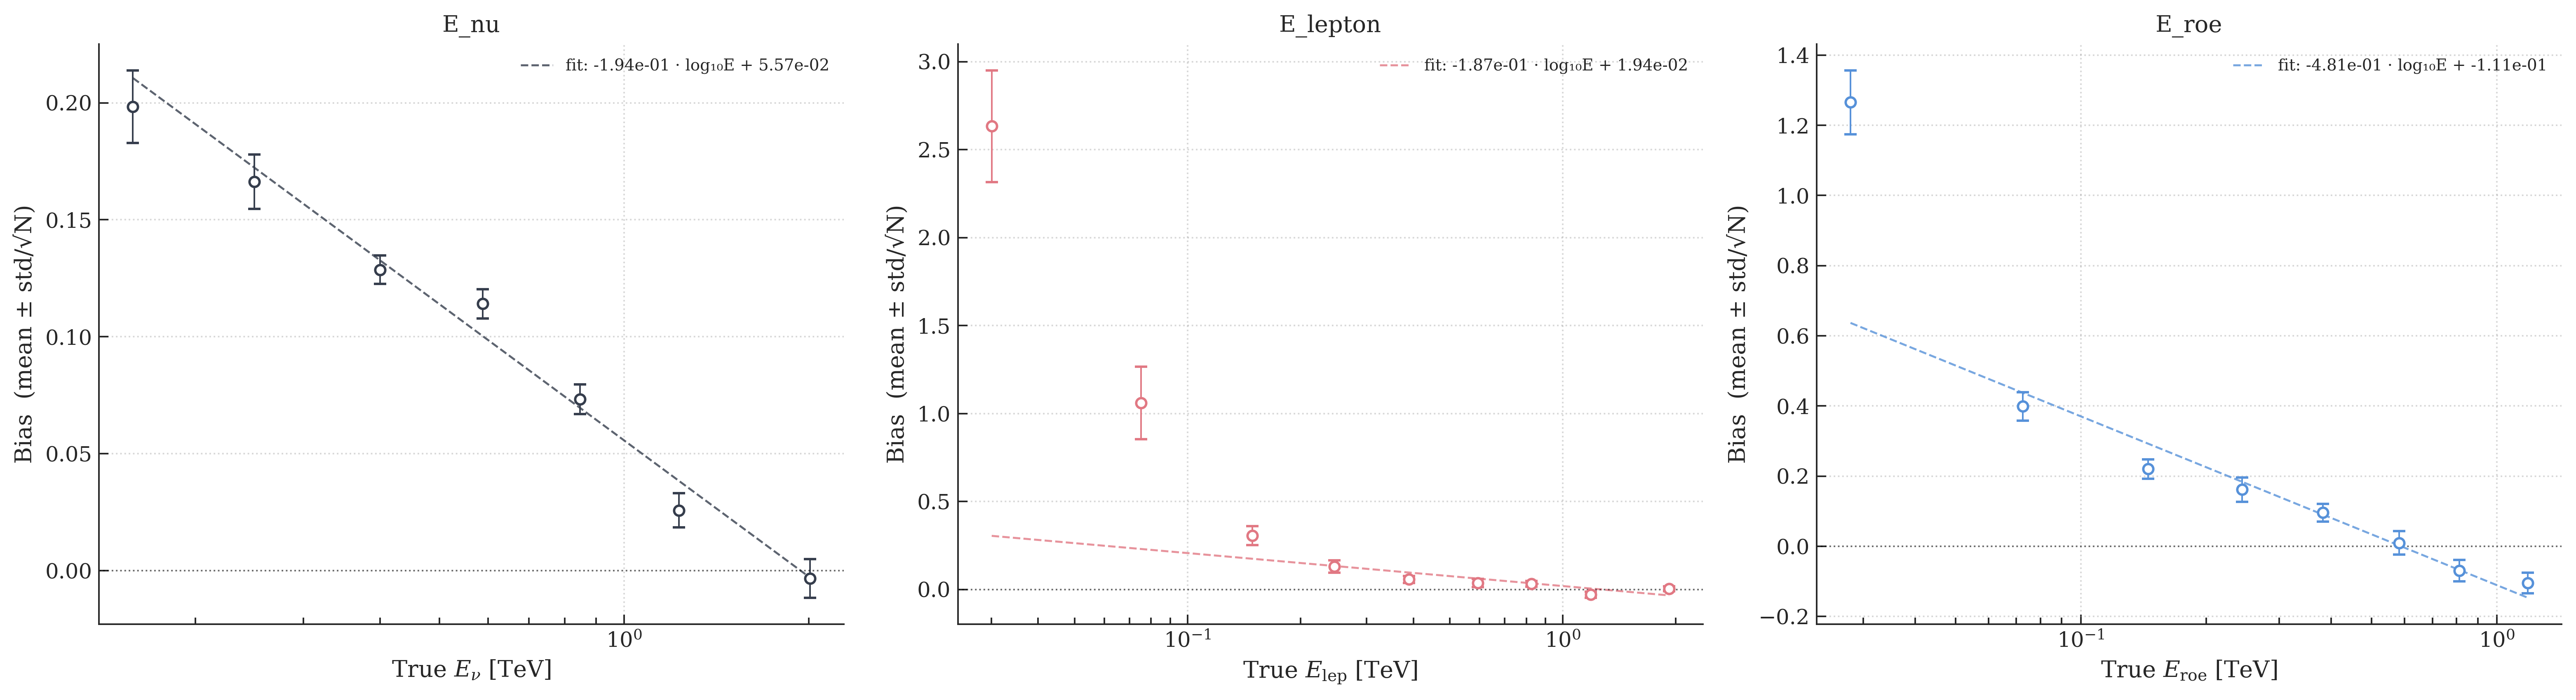

Saved: bias.png


In [64]:
def line_log(x, m, c):
    """Bias model: linear in log10(E)."""
    return m * np.log10(x) + c

fig, axes   = plt.subplots(1, 3, figsize=(18, 5))
bias_params = {}

for target_idx, (name, latex, col) in enumerate(zip(TARGET_NAMES, TARGET_LATEX, [C1, C2, C3])):
    ax         = axes[target_idx]
    y_true     = targets_linear[:, target_idx]
    y_pred     = preds_linear[:, target_idx]
    resolution = (y_pred - y_true) / y_true

    bin_centers = []
    means       = []
    mean_errs   = []
    ns          = []

    for emin, emax in ENERGY_BINS_TEV:
        mask    = (y_true >= emin) & (y_true < emax)
        res_bin = resolution[mask]
        n       = len(res_bin)
        if n < 50:
            continue
        sigma = np.std(res_bin)
        bin_centers.append(np.mean(y_true[mask]))
        means.append(np.mean(res_bin))
        mean_errs.append(sigma / np.sqrt(n))
        ns.append(n)

    if bin_centers:
        ax.errorbar(bin_centers, means, yerr=mean_errs,
                    fmt='o', markersize=5, capsize=3, linewidth=0.8,
                    color=col, markerfacecolor='white', markeredgewidth=1.2)

    if len(bin_centers) >= 2:
        try:
            popt, _ = curve_fit(
                line_log, bin_centers, means,
                sigma=mean_errs, absolute_sigma=True,
            )
            x_fit = np.logspace(
                np.log10(min(bin_centers)), np.log10(max(bin_centers)), 100
            )
            ax.plot(x_fit, line_log(x_fit, *popt),
                    color=col, linestyle='--', linewidth=1.0, alpha=0.8,
                    label=f"fit: {popt[0]:.2e} · log₁₀E + {popt[1]:.2e}")
            ax.legend(fontsize=8, frameon=False)
            bias_params[name] = popt
        except RuntimeError:
            pass

    ax.axhline(0, color="k", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.set_xscale("log")
    ax.set_xlabel(f"True {latex} [{TARGET_UNITS}]")
    ax.set_ylabel("Bias  (mean ± std/√N)")
    ax.set_title(name)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_path / "bias.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: bias.png")

**Summary**

In [ ]:
print(f"Best model : epoch {checkpoint['epoch'] + 1}")
print(f"Val MSE    : {checkpoint['val_loss']:.4f}")
print(f"Val RMSE   : {checkpoint['val_rmse']:.4f}")
print()
print(f"{'Target':<12} {'Median RelErr':>14} {'Std(res)':>10} {'Bias (mean)':>12}")

for i, name in enumerate(TARGET_NAMES):
    y_true  = targets_linear[:, i]
    y_pred  = preds_linear[:, i]
    rel_err = np.abs(y_pred - y_true) / y_true
    res     = (y_pred - y_true) / y_true
    print(f"{name:<12} {np.median(rel_err):>14.3f} {res.std():>10.3f} {res.mean():>+12.3f}")

print()
print(f"Figures: {figures_path}")

**Baseline: total calorimeter hits**

Each graph node stores log10(n_hits) for one calorimeter super-pixel. Summing 10^x over all nodes gives total raw hits — the same quantity as `len(hit_colID)` in `explore_tau_dataset.ipynb`, which correlates strongly with E_nu. A linear fit `E = a * total_hits + b` is the simplest possible reconstruction. GravNet should beat it, especially for E_lep and E_roe where the spatial shower structure matters.

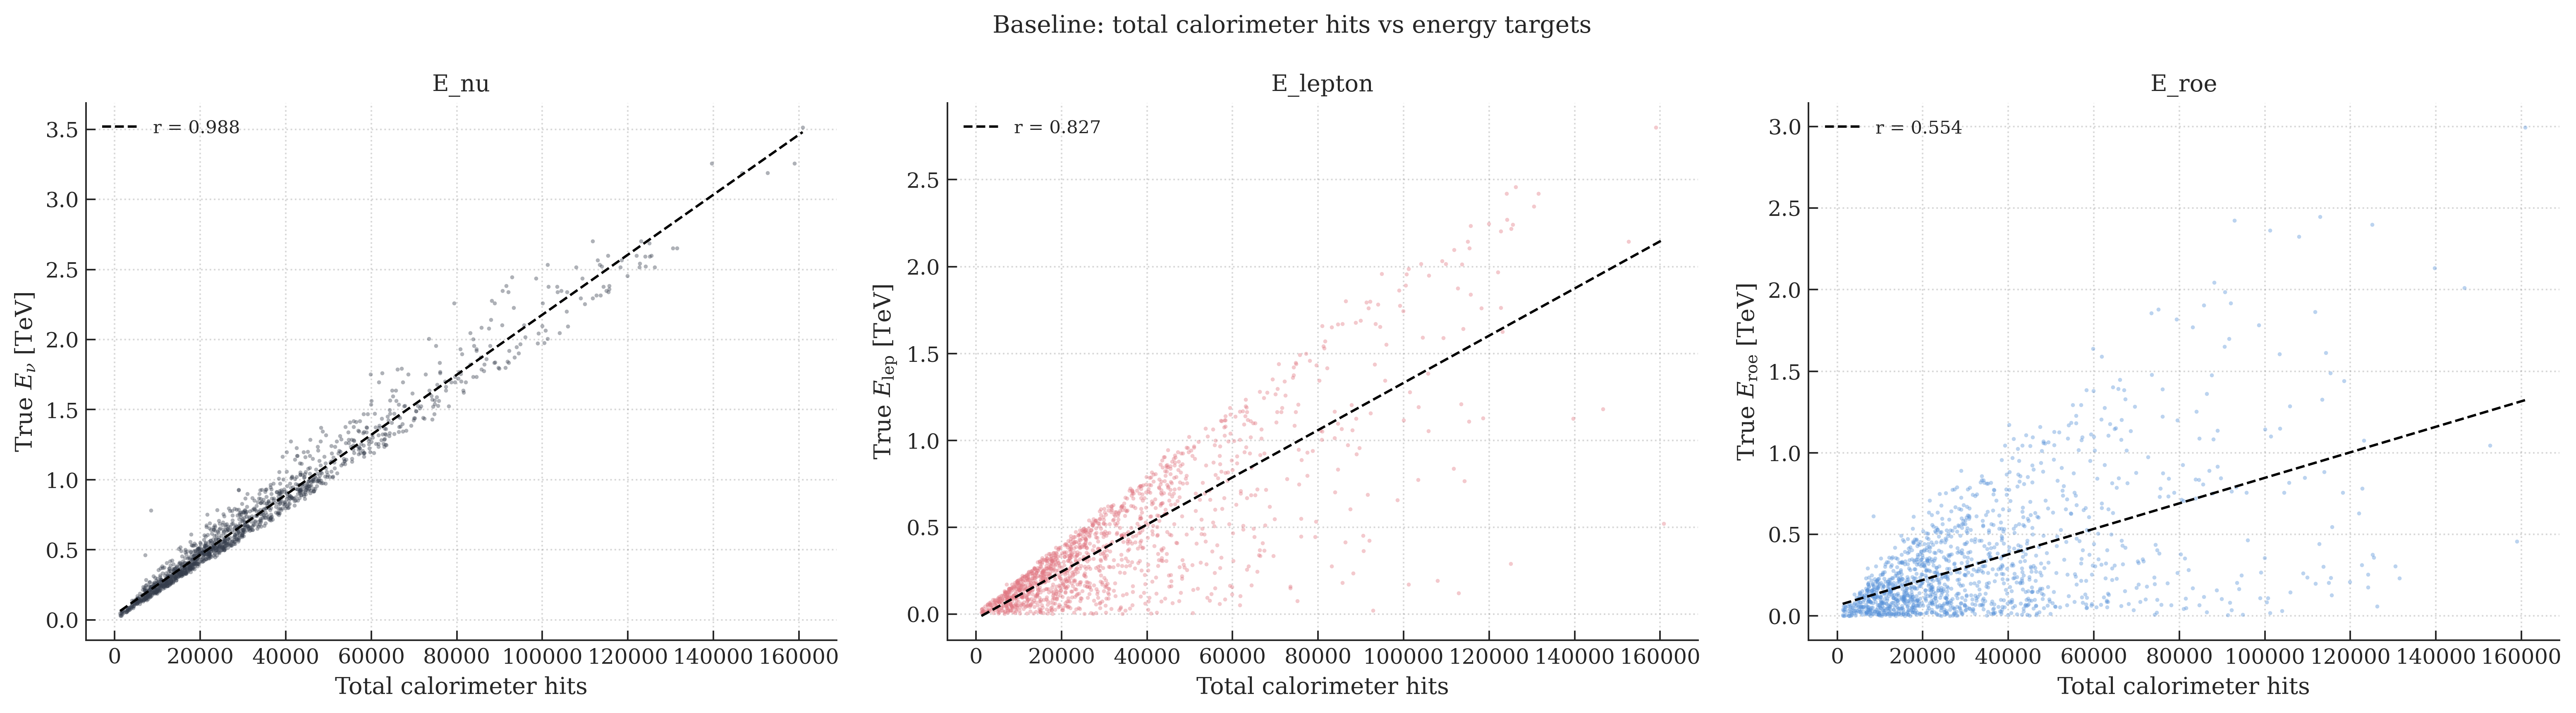

Saved: baseline_scatter.png


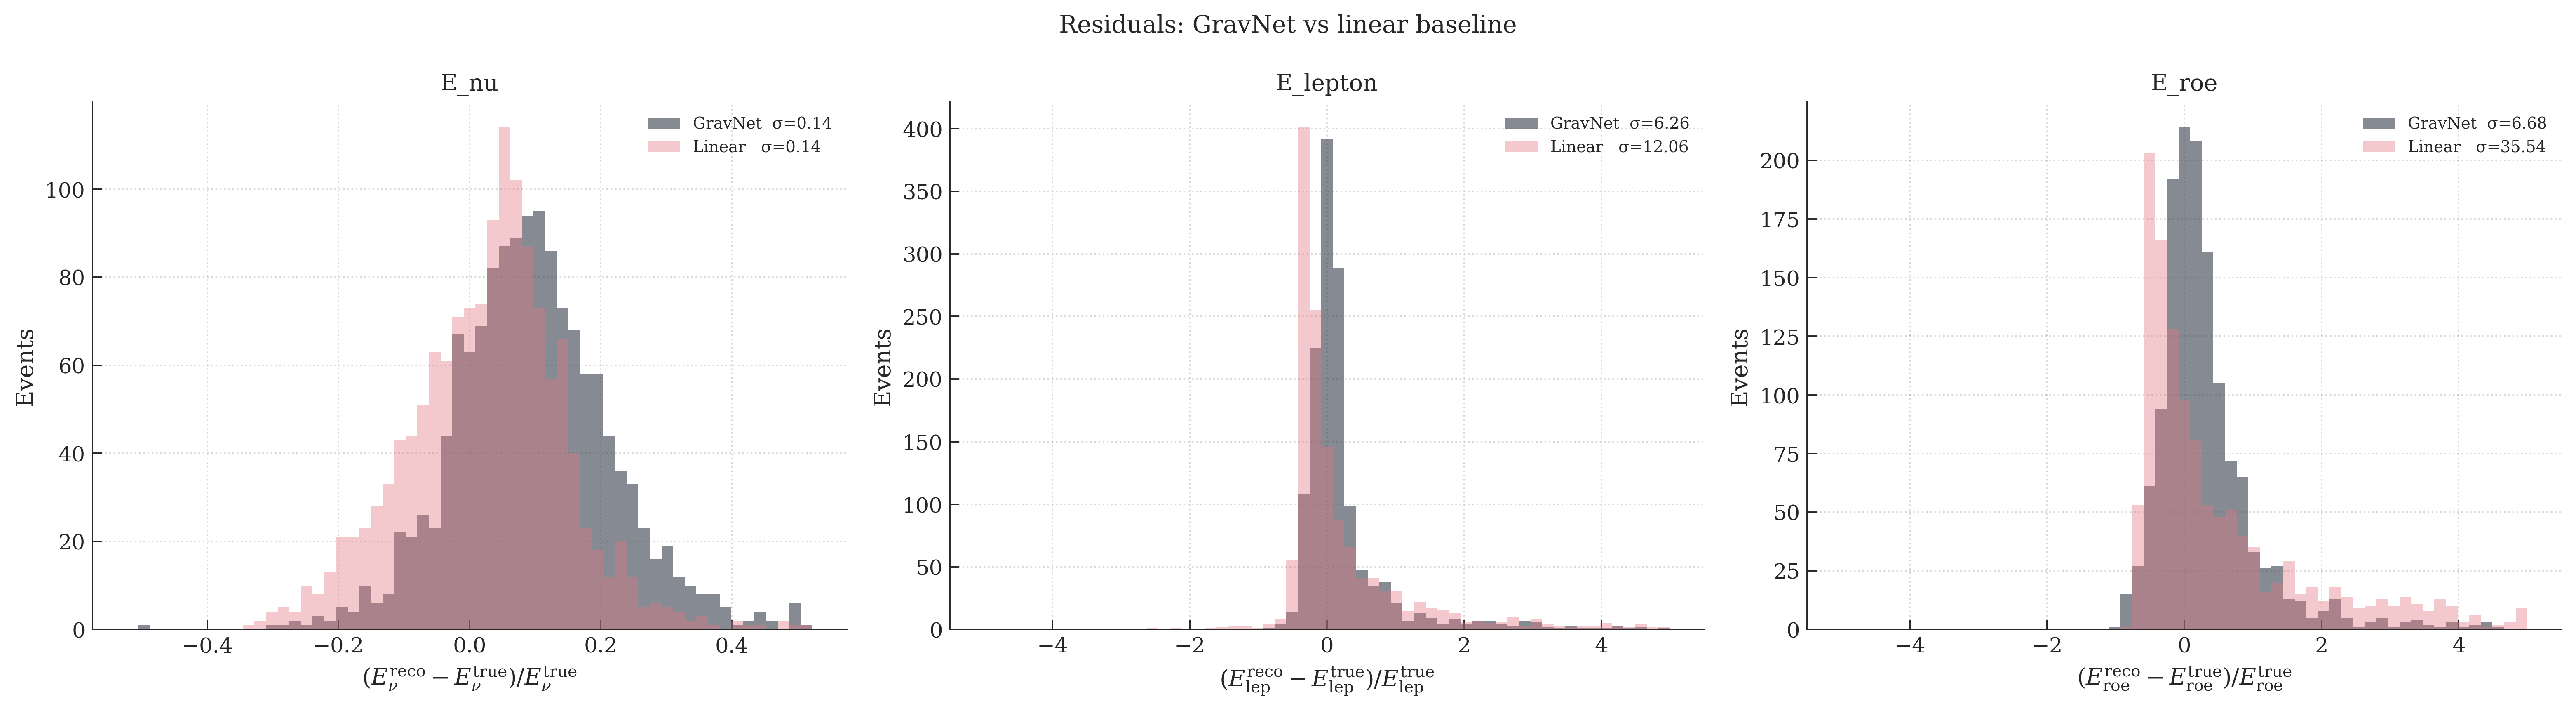

Saved: baseline_residuals.png


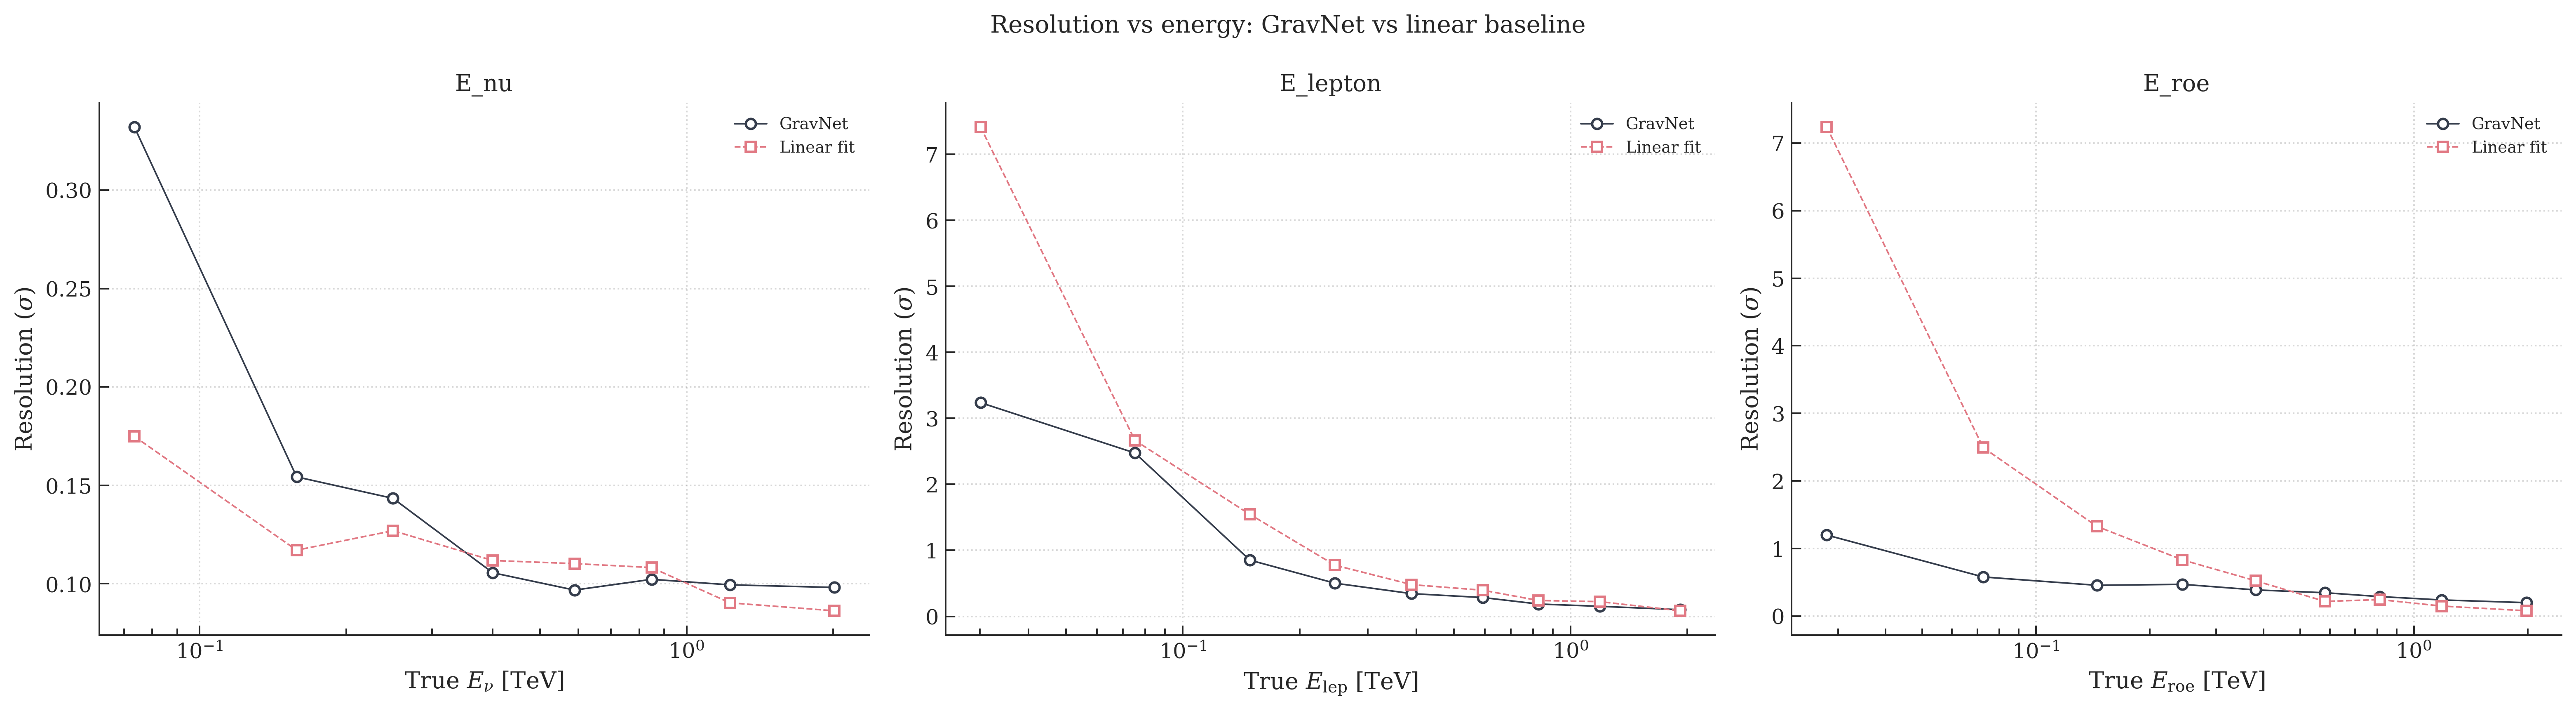

Saved: baseline_resolution.png

Target        GravNet std  Linear std   GravNet mean  Linear mean
E_nu                0.136       0.140         +0.100       +0.029
E_lepton            6.258      12.061         +0.961       +1.690
E_roe               6.682      35.538         +0.840       +4.803


In [66]:
# ── Total calorimeter hits per event ─────────────────────────────────────────
hits_list = []
for data in val_dataset:
    hits_list.append((10 ** data.x).sum().item())

total_hits_arr = np.array(hits_list)

# ── Linear fit for each target: E_target = a * total_hits + b ────────────────
coeffs_all       = []
linear_preds_all = []
for i in range(3):
    c = np.polyfit(total_hits_arr, targets_linear[:, i], 1)
    coeffs_all.append(c)
    linear_preds_all.append(np.polyval(c, total_hits_arr))

linear_res_all  = [
    (linear_preds_all[i] - targets_linear[:, i]) / targets_linear[:, i]
    for i in range(3)
]
gravnet_res_all = [
    (preds_linear[:, i] - targets_linear[:, i]) / targets_linear[:, i]
    for i in range(3)
]

# ── Figure 1: Hits scatter + fit ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, latex, col) in enumerate(zip(TARGET_NAMES, TARGET_LATEX, [C1, C2, C3])):
    ax = axes[i]
    r  = np.corrcoef(total_hits_arr, targets_linear[:, i])[0, 1]
    ax.scatter(total_hits_arr, targets_linear[:, i],
               s=4, alpha=0.4, color=col, linewidths=0)
    x_fit = np.linspace(total_hits_arr.min(), total_hits_arr.max(), 100)
    ax.plot(x_fit, np.polyval(coeffs_all[i], x_fit),
            color='k', linestyle='--', linewidth=1.2, label=f"r = {r:.3f}")
    ax.set_xlabel("Total calorimeter hits")
    ax.set_ylabel(rf"True {latex} [TeV]")
    ax.set_title(name)
    ax.legend(fontsize=9, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)
plt.suptitle("Baseline: total calorimeter hits vs energy targets", fontsize=12)
plt.tight_layout()
plt.savefig(figures_path / "baseline_scatter.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: baseline_scatter.png")

# ── Figure 2: Residual distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, latex) in enumerate(zip(TARGET_NAMES, TARGET_LATEX)):
    ax      = axes[i]
    gn_res  = gravnet_res_all[i]
    lin_res = linear_res_all[i]
    xlim    = min(np.percentile(np.abs(np.concatenate([gn_res, lin_res])), 99), 5.0)
    bins    = np.linspace(-xlim, xlim, 60)
    ax.hist(gn_res,  bins=bins, histtype='stepfilled', alpha=0.6, color=C1, linewidth=0,
            label=f"GravNet  σ={np.std(gn_res):.2f}")
    ax.hist(lin_res, bins=bins, histtype='stepfilled', alpha=0.4, color=C2, linewidth=0,
            label=f"Linear   σ={np.std(lin_res):.2f}")
    lx = latex.strip('$')
    ax.set_xlabel(rf"$({lx}^{{\rm reco}} - {lx}^{{\rm true}}) / {lx}^{{\rm true}}$")
    ax.set_ylabel("Events")
    ax.set_title(name)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)
plt.suptitle("Residuals: GravNet vs linear baseline", fontsize=12)
plt.tight_layout()
plt.savefig(figures_path / "baseline_residuals.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: baseline_residuals.png")

# ── Figure 3: Resolution vs energy ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, latex) in enumerate(zip(TARGET_NAMES, TARGET_LATEX)):
    ax      = axes[i]
    gn_res  = gravnet_res_all[i]
    lin_res = linear_res_all[i]
    gn_sigmas, lin_sigmas, centers_b = [], [], []
    for emin, emax in ENERGY_BINS_TEV:
        mask = (targets_linear[:, i] >= emin) & (targets_linear[:, i] < emax)
        if mask.sum() < 20:
            continue
        centers_b.append(np.mean(targets_linear[mask, i]))
        gn_sigmas.append(np.std(gn_res[mask]))
        lin_sigmas.append(np.std(lin_res[mask]))
    ax.plot(centers_b, gn_sigmas,  'o-',  markersize=5, linewidth=0.8,
            markerfacecolor='white', markeredgewidth=1.2, color=C1, label="GravNet")
    ax.plot(centers_b, lin_sigmas, 's--', markersize=5, linewidth=0.8,
            markerfacecolor='white', markeredgewidth=1.2, color=C2, label="Linear fit")
    ax.set_xscale("log")
    ax.set_xlabel(rf"True {latex} [TeV]")
    ax.set_ylabel(r"Resolution ($\sigma$)")
    ax.set_title(name)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)
plt.suptitle("Resolution vs energy: GravNet vs linear baseline", fontsize=12)
plt.tight_layout()
plt.savefig(figures_path / "baseline_resolution.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: baseline_resolution.png")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'Target':<12} {'GravNet std':>12} {'Linear std':>11} {'GravNet mean':>14} {'Linear mean':>12}")
for i, name in enumerate(TARGET_NAMES):
    print(f"{name:<12} {np.std(gravnet_res_all[i]):>12.3f} {np.std(linear_res_all[i]):>11.3f} "
          f"{np.mean(gravnet_res_all[i]):>+14.3f} {np.mean(linear_res_all[i]):>+12.3f}")

**Inelasticity and energy conservation**

Inelasticity y = E_lep / E_nu (fraction of neutrino energy carried by the lepton, 0–1 for CC events).

With the reparametrised model, predicted energies are derived as `E_lep = y·E_nu`, `E_roe = (1-y)·E_nu`, so `(E_lep + E_roe)/E_nu = y + (1-y) = 1` exactly for every event by construction. The conservation histogram for predictions should therefore be a delta function at 1 — this cell verifies that, and plots true vs predicted inelasticity as a diagnostic of how well the model predicts y directly.

Energy conservation check passed: max deviation = 1.19e-07


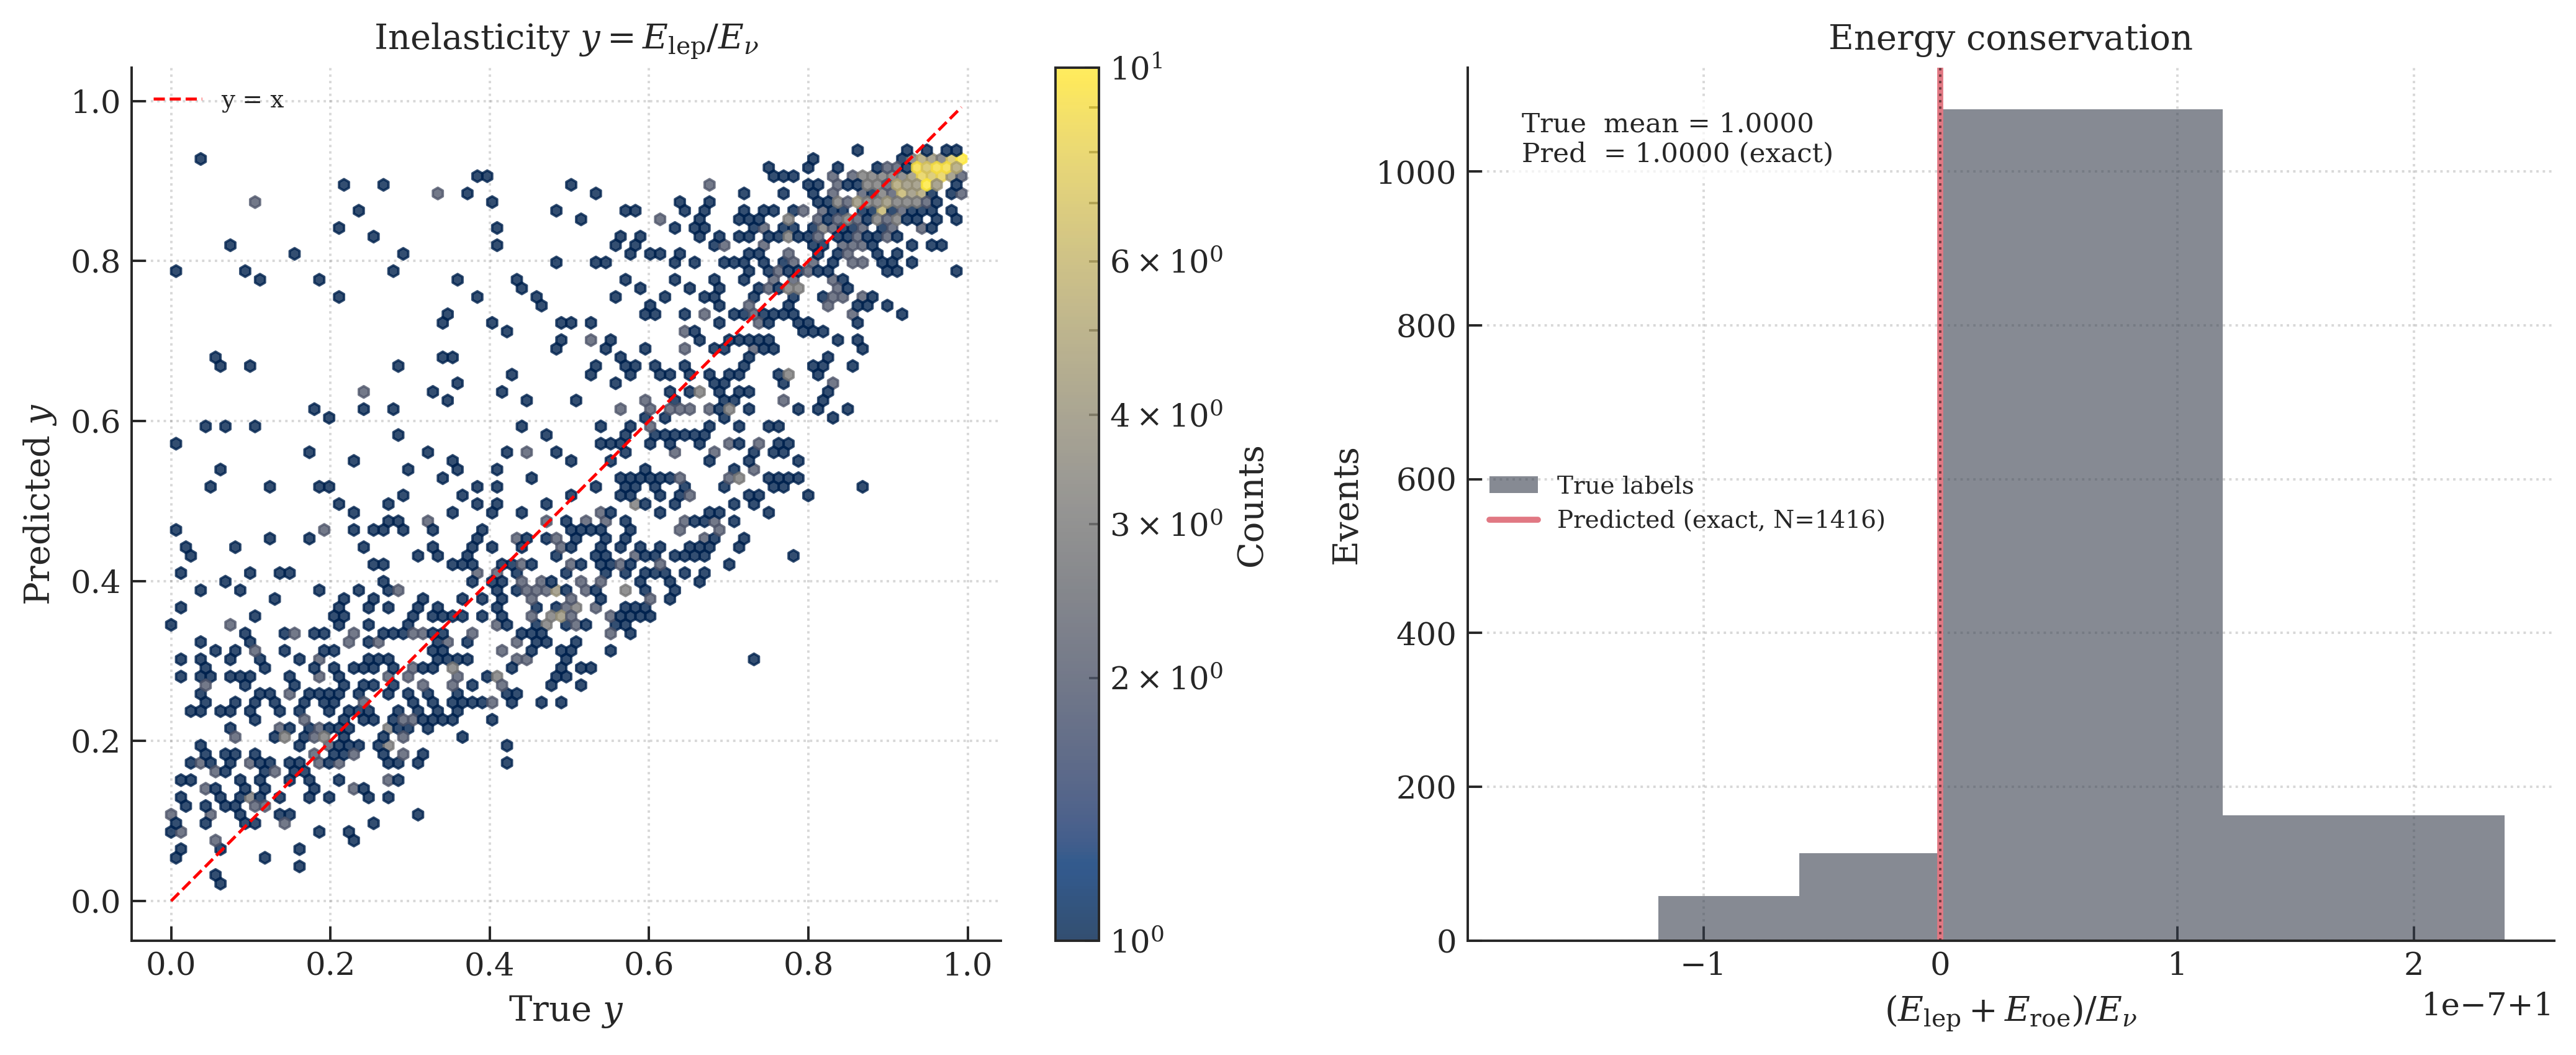

Saved: inelasticity_conservation.png


In [67]:
E_nu_true  = targets_linear[:, 0]
E_lep_true = targets_linear[:, 1]
E_roe_true = targets_linear[:, 2]
E_nu_pred  = preds_linear[:, 0]
E_lep_pred = preds_linear[:, 1]
E_roe_pred = preds_linear[:, 2]

inel_true = E_lep_true / E_nu_true.clip(min=1e-6)
inel_pred = E_lep_pred / E_nu_pred.clip(min=1e-6)

# Sanity check: reparametrised predictions must conserve energy exactly
cons_pred = (E_lep_pred + E_roe_pred) / E_nu_pred.clip(min=1e-6)
assert np.allclose(cons_pred, 1.0, atol=1e-5), \
    f"Energy conservation violated! max deviation = {np.abs(cons_pred - 1).max():.2e}"
print(f"Energy conservation check passed: max deviation = {np.abs(cons_pred - 1).max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Inelasticity 2D density
ax   = axes[0]
hi_i = min(max(np.percentile(inel_true, 99), np.percentile(inel_pred, 99)), 3.0)
hb   = ax.hexbin(inel_true, inel_pred,
                 gridsize=80, cmap='cividis', bins='log',
                 mincnt=1, alpha=0.8,
                 extent=[0, hi_i, 0, hi_i])
plt.colorbar(hb, ax=ax, label='Counts')
ax.plot([0, hi_i], [0, hi_i], "r--", linewidth=1, label="y = x")
ax.set_xlabel("True $y$")
ax.set_ylabel("Predicted $y$")
ax.set_title(r"Inelasticity $y = E_\mathrm{lep} / E_\nu$")
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)

# Energy conservation
ax        = axes[1]
cons_true = (E_lep_true + E_roe_true) / E_nu_true.clip(min=1e-6)
spread    = np.percentile(np.abs(cons_true - 1), 99)
xlim_c    = min(spread * 1.5, 3.0)
bins_c    = np.linspace(max(0.0, 1 - xlim_c), 1 + xlim_c, 60)
ax.hist(cons_true, bins=bins_c, histtype='stepfilled', alpha=0.6, color=C1,
        linewidth=0, label="True labels")
ax.axvline(1.0, color=C2, linestyle="-", linewidth=2,
           label=f"Predicted (exact, N={len(cons_pred)})")
ax.axvline(1.0, color="k", linestyle=":", linewidth=0.8, alpha=0.5)
ax.set_xlabel(r"$(E_\mathrm{lep} + E_\mathrm{roe}) / E_\nu$")
ax.set_ylabel("Events")
ax.set_title("Energy conservation")
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle=':', linewidth=0.8, color='gray', alpha=0.3)
ax.text(0.05, 0.95,
        f"True  mean = {cons_true.mean():.4f}\nPred  = 1.0000 (exact)",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig(figures_path / "inelasticity_conservation.png", dpi=500, bbox_inches='tight')
plt.show()
print("Saved: inelasticity_conservation.png")

Poss future additions

- Best/worst event display: sort val_dataset by |pred − true| / true, visualise graph hits of best and worst events.
- Containment study: filter by vertex vz within detector acceptance. Check data.keys() and available parquet columns first.